# Cell 1: Import Week 3 Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpmath as mp
import time

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, learning_curve
from sklearn.base import clone

from scipy.special import iv, kv, ive, kve
from scipy.signal import savgol_filter

## Cell 1A: Matplotlib global settings

In [2]:
plt.rcParams["legend.fontsize"] = 12  # To change font size
plt.rcParams["font.family"] = "Times New Roman"  # To change overall font family
plt.rcParams["font.weight"] ="bold"# To change overall font weight

# Cell 2: Load and Verify the Dataset

In [3]:
df = pd.read_csv(
    "well_test_ml_dataset.csv"
)

print("Dataset shape:", df.shape)
print()
print(df["split"].value_counts())

df.head()

Dataset shape: (500, 20)

split
test     400
train    100
Name: count, dtype: int64


,case_id,P_0.01hr,P_0.03hr,P_0.1hr,P_0.5hr,P_1hr,P_3hr,P_10hr,P_30hr,D_0.01hr,D_0.03hr,D_0.1hr,D_0.5hr,D_1hr,D_3hr,D_10hr,D_30hr,k_mD,skin,split
0,0,36.468076,82.739589,139.367281,169.002608,176.567229,187.741173,199.479101,205.630761,30.875022,51.196171,33.992339,11.160352,10.704383,9.232693,9.227667,1.544837,87.417221,2.887132,test
1,1,16.927340,36.938630,58.977468,70.794546,74.197383,79.325972,86.971003,107.066707,13.884581,21.307189,12.528786,5.196747,4.954996,4.877955,9.983938,30.329353,191.128575,1.752675,train
2,2,11.941573,28.142182,52.124393,69.916107,77.054810,104.167076,199.304201,470.692406,10.262839,19.012102,17.361092,8.072484,13.579102,40.557041,135.072099,406.699555,151.758910,0.166693,test
3,3,14.987518,38.918578,85.772106,127.107594,133.241692,141.555478,154.003207,187.106075,13.775021,31.008823,41.557867,10.792685,8.127927,7.213263,16.970314,49.933416,127.758527,3.696565,test
4,4,14.509790,40.832910,112.355256,261.370931,297.112173,324.989758,348.256911,361.841159,14.090247,37.192522,84.071064,71.292736,35.899134,20.477935,17.467782,6.898818,48.083355,2.793118,test


# Cell 3: Reconstruct the Frozen Train/Test Sets

In [4]:
feature_columns = [
    col for col in df.columns
    if col.startswith("P_")
    or col.startswith("D_")
]

target_columns = [
    "k_mD",
    "skin"
]

train_df = df[
    df["split"] == "train"
].copy()

test_df = df[
    df["split"] == "test"
].copy()

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]

y_train = train_df[target_columns]
y_test = test_df[target_columns]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (100, 16)
X_test : (400, 16)
y_train: (100, 2)
y_test : (400, 2)


# Cell 4: Inspect Feature Scales

In [5]:
feature_stats = X_train.describe().T[
    ["min", "max", "mean", "std"]
]

feature_stats

,min,max,mean,std
P_0.01hr,9.817407,72.488816,23.720925,15.425735
P_0.03hr,21.639785,178.373616,53.175005,33.603864
P_0.1hr,31.189648,351.730005,101.819464,64.536494
P_0.5hr,38.836955,535.641887,167.963739,129.277512
P_1hr,41.996034,675.412021,188.247869,156.769752
P_3hr,46.632165,841.711198,209.485852,180.273453
P_10hr,46.606273,902.123977,231.837962,193.237187
P_30hr,46.599649,915.427139,267.769477,214.767025
D_0.01hr,7.016311,64.629964,19.224480,12.546453
D_0.03hr,5.676921,129.570410,34.484897,23.724221


# Cell 5: Standardize the Features

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# Cell 6: Verify the Scaling

In [7]:
print(
    "Mean of scaled training features:",
    np.mean(X_train_scaled, axis=0)
)

print()

print(
    "Std of scaled training features:",
    np.std(X_train_scaled, axis=0)
)

Mean of scaled training features: [-2.04281037e-16  2.10942375e-16  2.04281037e-16  7.10542736e-17
 -3.33066907e-18  3.66373598e-17 -1.77635684e-16  5.88418203e-17
  8.32667268e-17 -1.45439216e-16  1.16573418e-16  5.55111512e-18
  9.21485110e-17 -1.63202785e-16 -4.70803951e-17  3.46944695e-17]

Std of scaled training features: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Cell 7: Create Random Forest

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Cell 8: Train the Random Forest

## Cell 8A: Train the Combined Random Forest model

In [9]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

## Cell 8B: Train the Separate Random Forest models

In [10]:
rf_k = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_skin = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train independently
rf_k.fit(X_train, y_train["k_mD"])
rf_skin.fit(X_train, y_train["skin"])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

# Cell 9: Make Predictions

## Cell 9A: Make Predictions from combined model

In [11]:
y_train_pred_rf = rf_model.predict(
    X_train
)

y_test_pred_rf = rf_model.predict(
    X_test
)

print(
    "Training predictions:",
    y_train_pred_rf.shape
)

print(
    "Testing predictions:",
    y_test_pred_rf.shape
)

Training predictions: (100, 2)
Testing predictions: (400, 2)


In [12]:
print("True:")
print(y_test.iloc[:5].values)

print("\nPredicted:")
print(y_test_pred_rf[:5])

True:
[[ 87.41722139   2.887132  ]
 [151.75890953   0.16669331]
 [127.75852716   3.69656514]
 [ 48.08335528   2.79311821]
 [ 48.07901366  -0.86168142]]

Predicted:
[[ 92.37103999   2.48656208]
 [132.86912719   0.85916857]
 [124.04181386   3.33800724]
 [ 47.39668421   2.45343094]
 [ 54.24456341   0.48438496]]


## Cell 9B: Make Predictions from separate models

In [13]:
k_train_pred_rf = rf_k.predict(X_train)
k_test_pred_rf  = rf_k.predict(X_test)

skin_train_pred_rf = rf_skin.predict(X_train)
skin_test_pred_rf  = rf_skin.predict(X_test)

print(
    "Training predictions for Permeability:",
    k_train_pred_rf.shape
)

print(
    "Training predictions for Skin:",
    skin_train_pred_rf.shape
)

print(
    "Testing predictions for Permeability:",
    k_test_pred_rf.shape
)

print(
    "Training predictions for Skin:",
    skin_test_pred_rf.shape
)

Training predictions for Permeability: (100,)
Training predictions for Skin: (100,)
Testing predictions for Permeability: (400,)
Training predictions for Skin: (400,)


In [14]:
print("True:")
print(y_test.iloc[:5].values)

print("\nPredicted:")
print(np.array(list(zip(k_test_pred_rf[:5], skin_test_pred_rf[:5]))))

True:
[[ 87.41722139   2.887132  ]
 [151.75890953   0.16669331]
 [127.75852716   3.69656514]
 [ 48.08335528   2.79311821]
 [ 48.07901366  -0.86168142]]

Predicted:
[[ 92.31465968   3.21015543]
 [133.27582974  -0.18432838]
 [124.03562051   3.15229832]
 [ 47.64220693   2.33842249]
 [ 54.43687741   0.54233448]]


# Cell 10: Calculate Performance Metrics

In [15]:
train_predictions_rf = [
    k_train_pred_rf,
    skin_train_pred_rf
]

test_predictions_rf = [
    k_test_pred_rf,
    skin_test_pred_rf
]

# Evaluate separate Random Forest models
for i, target in enumerate(target_columns):

    train_mae = mean_absolute_error(
        y_train.iloc[:, i],
        train_predictions_rf[i]
    )

    test_mae = mean_absolute_error(
        y_test.iloc[:, i],
        test_predictions_rf[i]
    )

    train_mse = mean_squared_error(
        y_train.iloc[:, i],
        train_predictions_rf[i]
    )

    test_mse = mean_squared_error(
        y_test.iloc[:, i],
        test_predictions_rf[i]
    )

    train_r2 = r2_score(
        y_train.iloc[:, i],
        train_predictions_rf[i]
    )

    test_r2 = r2_score(
        y_test.iloc[:, i],
        test_predictions_rf[i]
    )

    print(f"\nTarget: {target}")

    print(f"Train MAE: {train_mae:.4f}")
    print(f"Test MAE : {test_mae:.4f}")

    print(f"Train MSE: {train_mse:.4f}")
    print(f"Test MSE : {test_mse:.4f}")

    print(f"Train R² : {train_r2:.4f}")
    print(f"Test R²  : {test_r2:.4f}")


Target: k_mD
Train MAE: 3.6870
Test MAE : 7.9985
Train MSE: 33.3109
Test MSE : 122.4205
Train R² : 0.9908
Test R²  : 0.9546

Target: skin
Train MAE: 0.4619
Test MAE : 0.8429
Train MSE: 0.3322
Test MSE : 1.0940
Train R² : 0.9342
Test R²  : 0.7050


In [16]:
print("PERMEABILITY")
print("Joint RF R²:",
      r2_score(y_test["k_mD"], y_test_pred_rf[:, 0]))
print("Separate RF R²:",
      r2_score(y_test["k_mD"], k_test_pred_rf))

print("\nSKIN")
print("Joint RF R²:",
      r2_score(y_test["skin"], y_test_pred_rf[:, 1]))
print("Separate RF R²:",
      r2_score(y_test["skin"], skin_test_pred_rf))

PERMEABILITY
Joint RF R²: 0.9536590569339455
Separate RF R²: 0.9546324555633224

SKIN
Joint RF R²: 0.7007360131055428
Separate RF R²: 0.7050292181866229


In [17]:
print("PERMEABILITY")
print("Joint RF MAE:",
      mean_absolute_error(y_test["k_mD"], y_test_pred_rf[:, 0]))
print("Separate RF MAE:",
      mean_absolute_error(y_test["k_mD"], k_test_pred_rf))

print("\nSKIN")
print("Joint RF MAE:",
      mean_absolute_error(y_test["skin"], y_test_pred_rf[:, 1]))
print("Separate RF MAE:",
      mean_absolute_error(y_test["skin"], skin_test_pred_rf))

PERMEABILITY
Joint RF MAE: 8.081320225998153
Separate RF MAE: 7.998525647977556

SKIN
Joint RF MAE: 0.8736767116510665
Separate RF MAE: 0.8429190260785308


# Cell 11: Random Forest Parity Plots

## Cell 11A: Random Forest — Permeability Parity Plot

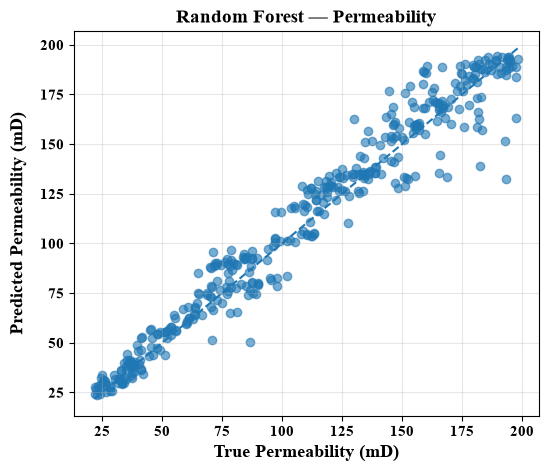

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test["k_mD"], y_test_pred_rf[:, 0], alpha=0.6)

ax.plot([y_test["k_mD"].min(), y_test["k_mD"].max()], [y_test["k_mD"].min(), y_test["k_mD"].max()], "--")

ax.set_xlabel("True Permeability (mD)", fontweight="bold", fontsize=13)

ax.set_ylabel("Predicted Permeability (mD)", fontweight="bold", fontsize=13, labelpad=10)

ax.set_title("Random Forest — Permeability", fontweight="bold", fontsize=14)

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Random Forest_Permeability Parity Plot.jpeg", dpi=300)

plt.show()

## Cell 11B: Random Forest — Skin Parity Plot

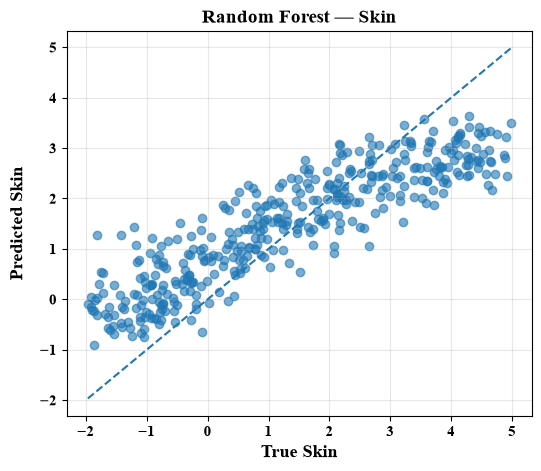

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test["skin"], y_test_pred_rf[:, 1], alpha=0.6)

ax.plot([y_test["skin"].min(), y_test["skin"].max()], [y_test["skin"].min(), y_test["skin"].max()], "--")

ax.set_xlabel("True Skin", fontweight="bold", fontsize=13)

ax.set_ylabel("Predicted Skin", fontweight="bold", fontsize=13,labelpad=10)

ax.set_title("Random Forest — Skin", fontweight="bold", fontsize=14)

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)
    
fig.savefig("Random Forest_Skin Parity Plot.jpeg", dpi = 300)

plt.show()

## Cell 11C: Separate Random Forest — Permeability Parity Plot

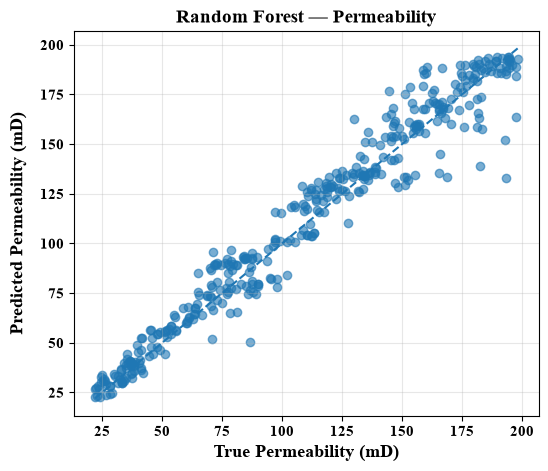

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test["k_mD"], k_test_pred_rf, alpha=0.6)

ax.plot([y_test["k_mD"].min(), y_test["k_mD"].max()], [y_test["k_mD"].min(), y_test["k_mD"].max()], "--")

ax.set_xlabel("True Permeability (mD)", fontweight="bold", fontsize=13)

ax.set_ylabel("Predicted Permeability (mD)", fontweight="bold", fontsize=13, labelpad=10)

ax.set_title("Random Forest — Permeability", fontweight="bold", fontsize=14)

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Separate Random Forest_Permeability Parity Plot.jpeg", dpi=300)

plt.show()

## Cell 11D: Separate Random Forest — Skin Parity Plot

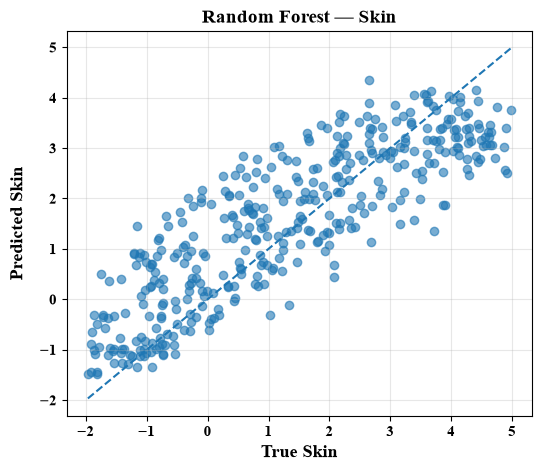

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test["skin"], skin_test_pred_rf, alpha=0.6)

ax.plot([y_test["skin"].min(), y_test["skin"].max()], [y_test["skin"].min(), y_test["skin"].max()], "--")

ax.set_xlabel("True Skin", fontweight="bold", fontsize=13)

ax.set_ylabel("Predicted Skin", fontweight="bold", fontsize=13,labelpad=10)

ax.set_title("Random Forest — Skin", fontweight="bold", fontsize=14)

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)
    
fig.savefig("Separate Random Forest_Skin Parity Plot.jpeg", dpi = 300)

plt.show()

# Cell 12: Create Gradient Boosting Model

In [22]:
gb_base = GradientBoostingRegressor(
    random_state=42
)

gb_model = MultiOutputRegressor(
    gb_base
)

# Cell 13: Train and Predict

In [23]:
gb_model.fit(
    X_train,
    y_train
)

y_train_pred_gb = gb_model.predict(
    X_train
)

y_test_pred_gb = gb_model.predict(
    X_test
)

print(
    "Training predictions:",
    y_train_pred_gb.shape
)

print(
    "Testing predictions:",
    y_test_pred_gb.shape
)

Training predictions: (100, 2)
Testing predictions: (400, 2)


# Cell 14: Gradient Boosting Performance Metrics

In [24]:
for i, target in enumerate(target_columns):

    train_mae = mean_absolute_error(
        y_train.iloc[:, i],
        y_train_pred_gb[:, i]
    )

    test_mae = mean_absolute_error(
        y_test.iloc[:, i],
        y_test_pred_gb[:, i]
    )

    train_mse = mean_squared_error(
        y_train.iloc[:, i],
        y_train_pred_gb[:, i]
    )

    test_mse = mean_squared_error(
        y_test.iloc[:, i],
        y_test_pred_gb[:, i]
    )

    train_r2 = r2_score(
        y_train.iloc[:, i],
        y_train_pred_gb[:, i]
    )

    test_r2 = r2_score(
        y_test.iloc[:, i],
        y_test_pred_gb[:, i]
    )

    print(f"\nTarget: {target}")

    print(f"Train MAE: {train_mae:.4f}")
    print(f"Test MAE : {test_mae:.4f}")

    print(f"Train MSE: {train_mse:.4f}")
    print(f"Test MSE : {test_mse:.4f}")

    print(f"Train R² : {train_r2:.4f}")
    print(f"Test R²  : {test_r2:.4f}")


Target: k_mD
Train MAE: 0.6855
Test MAE : 7.5892
Train MSE: 0.7646
Test MSE : 105.9515
Train R² : 0.9998
Test R²  : 0.9607

Target: skin
Train MAE: 0.1170
Test MAE : 0.7756
Train MSE: 0.0214
Test MSE : 1.0054
Train R² : 0.9958
Test R²  : 0.7289


# Cell 15: Gradient Boosting Parity Plots

## Cell 15A: Gradient Boosting — Permeability Parity Plot

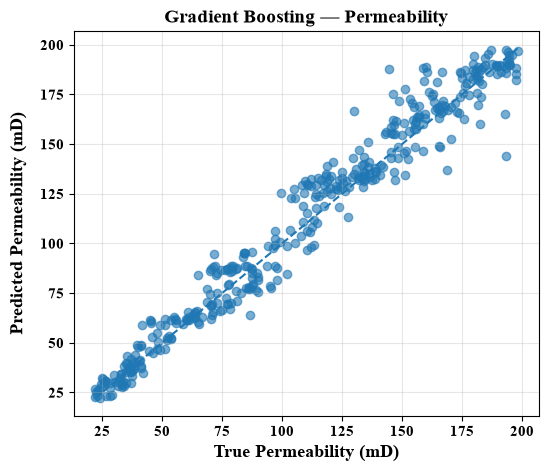

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test["k_mD"], y_test_pred_gb[:, 0], alpha=0.6)

ax.plot([y_test["k_mD"].min(), y_test["k_mD"].max()], [y_test["k_mD"].min(), y_test["k_mD"].max()], "--")

ax.set_xlabel("True Permeability (mD)", fontweight="bold", fontsize=13)

ax.set_ylabel("Predicted Permeability (mD)", fontweight="bold", fontsize=13, labelpad=10)

ax.set_title("Gradient Boosting — Permeability", fontweight="bold", fontsize=14)

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Gradient Boosting_Permeability Parity Plot.jpeg", dpi=300)

plt.show()

## Cell 15B: Gradient Boosting — Skin Parity Plot

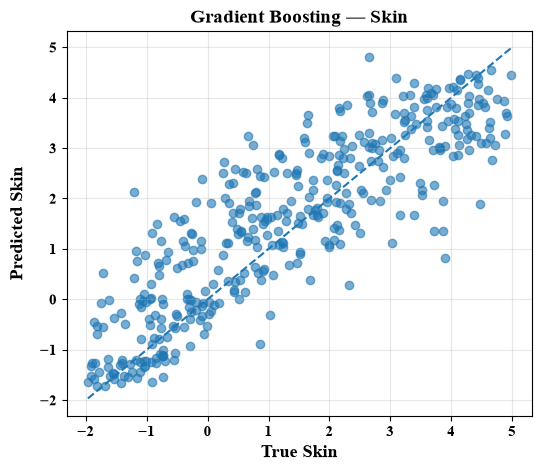

In [26]:
fig,ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test["skin"], y_test_pred_gb[:, 1], alpha=0.6)

ax.plot([y_test["skin"].min(), y_test["skin"].max()], [y_test["skin"].min(), y_test["skin"].max()], "--")

ax.set_xlabel("True Skin", fontweight="bold", fontsize=13)

ax.set_ylabel("Predicted Skin", fontweight="bold", fontsize=13,labelpad=10)

ax.set_title("Gradient Boosting — Skin", fontweight="bold", fontsize=14)

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Gradient Boosting_Skin Parity Plot.jpeg", dpi = 300)

plt.show()

# Cell 16: Gradient Boosting Feature Importance

In [27]:
importance_k = (gb_model.estimators_[0].feature_importances_)

importance_skin = (gb_model.estimators_[1].feature_importances_)

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "k_importance": importance_k,
    "skin_importance": importance_skin
})

importance_df

,Feature,k_importance,skin_importance
0,P_0.01hr,0.001477,0.008564
1,P_0.03hr,0.002566,0.006381
2,P_0.1hr,0.002956,0.192874
3,P_0.5hr,0.001229,0.047282
4,P_1hr,0.000301,0.014472
5,P_3hr,0.000484,0.004469
6,P_10hr,0.002248,0.044260
7,P_30hr,0.000943,0.081879
8,D_0.01hr,0.001409,0.009083
9,D_0.03hr,0.000297,0.222635


In [28]:
print("Most important features for permeability:")

print(
    importance_df[
        ["Feature", "k_importance"]
    ]
    .sort_values(
        "k_importance",
        ascending=False
    )
)

print("\nMost important features for skin:")

print(
    importance_df[
        ["Feature", "skin_importance"]
    ]
    .sort_values(
        "skin_importance",
        ascending=False
    )
)

Most important features for permeability:
     Feature  k_importance
11   D_0.5hr      0.791997
12     D_1hr      0.173917
13     D_3hr      0.010966
14    D_10hr      0.003867
10   D_0.1hr      0.003594
2    P_0.1hr      0.002956
1   P_0.03hr      0.002566
6     P_10hr      0.002248
15    D_30hr      0.001750
0   P_0.01hr      0.001477
8   D_0.01hr      0.001409
3    P_0.5hr      0.001229
7     P_30hr      0.000943
5      P_3hr      0.000484
4      P_1hr      0.000301
9   D_0.03hr      0.000297

Most important features for skin:
     Feature  skin_importance
9   D_0.03hr         0.222635
2    P_0.1hr         0.192874
12     D_1hr         0.151977
7     P_30hr         0.081879
10   D_0.1hr         0.073549
11   D_0.5hr         0.049715
3    P_0.5hr         0.047282
6     P_10hr         0.044260
15    D_30hr         0.032861
13     D_3hr         0.031102
14    D_10hr         0.028899
4      P_1hr         0.014472
8   D_0.01hr         0.009083
0   P_0.01hr         0.008564
1   P_0.03hr  

# Cell 17: Feature Importance Plots

## Cell 17A: Gradient Boosting — Permeability Feature Importance Plot

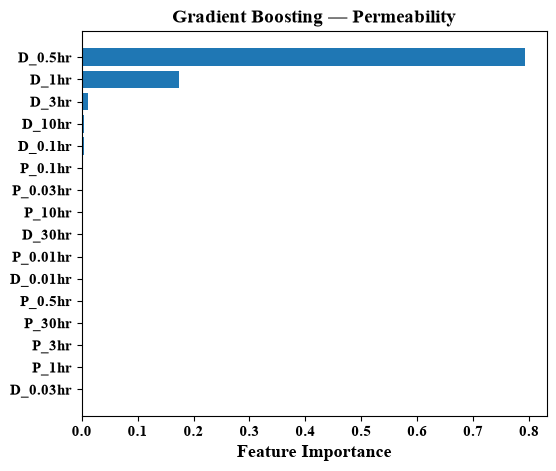

In [29]:
fig,ax = plt.subplots(figsize=(6, 5))

k_sorted = importance_df.sort_values("k_importance")

ax.barh(k_sorted["Feature"], k_sorted["k_importance"])

ax.set_xlabel("Feature Importance", fontweight="bold", fontsize=13)

ax.set_title("Gradient Boosting — Permeability",fontweight="bold", fontsize=14)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Gradient Boosting_Permeability Feature Importance Plot.jpeg", dpi = 300)

plt.show()

## Cell 17B: Gradient Boosting — Skin Feature Importance Plot

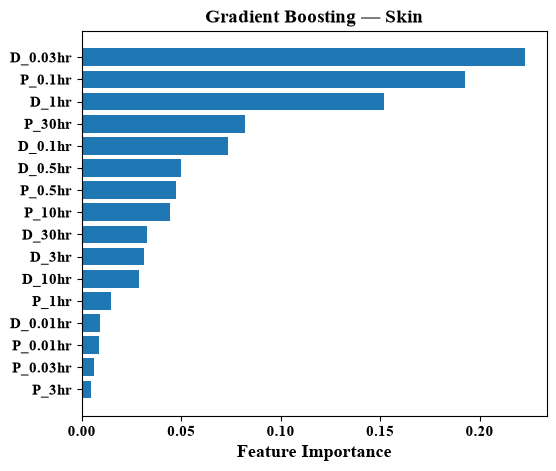

In [30]:
fig,ax = plt.subplots(figsize=(6, 5))

s_sorted = importance_df.sort_values("skin_importance")

ax.barh(s_sorted["Feature"], s_sorted["skin_importance"])

ax.set_xlabel("Feature Importance", fontweight="bold", fontsize=13)

ax.set_title("Gradient Boosting — Skin",fontweight="bold", fontsize=14)

ax.tick_params(axis='both', labelsize=11)
    
fig.savefig("Gradient Boosting_Skin Feature Importance Plot.jpeg", dpi = 300)

plt.show()

# Cell 18: Ridge Regression Baseline

In [31]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_train_pred_ridge = ridge_model.predict(X_train_scaled)

y_test_pred_ridge = ridge_model.predict(X_test_scaled)

# Cell 19: Evaluate Ridge

In [32]:
for i, target in enumerate(target_columns):

    train_mae = mean_absolute_error(
        y_train.iloc[:, i],
        y_train_pred_ridge[:, i]
    )

    test_mae = mean_absolute_error(
        y_test.iloc[:, i],
        y_test_pred_ridge[:, i]
    )

    train_mse = mean_squared_error(
        y_train.iloc[:, i],
        y_train_pred_ridge[:, i]
    )

    test_mse = mean_squared_error(
        y_test.iloc[:, i],
        y_test_pred_ridge[:, i]
    )

    train_r2 = r2_score(
        y_train.iloc[:, i],
        y_train_pred_ridge[:, i]
    )

    test_r2 = r2_score(
        y_test.iloc[:, i],
        y_test_pred_ridge[:, i]
    )

    print(f"\nTarget: {target}")

    print(f"Train MAE: {train_mae:.4f}")
    print(f"Test MAE : {test_mae:.4f}")

    print(f"Train MSE: {train_mse:.4f}")
    print(f"Test MSE : {test_mse:.4f}")

    print(f"Train R² : {train_r2:.4f}")
    print(f"Test R²  : {test_r2:.4f}")


Target: k_mD
Train MAE: 27.8603
Test MAE : 25.8548
Train MSE: 1089.9908
Test MSE : 917.6026
Train R² : 0.6997
Test R²  : 0.6599

Target: skin
Train MAE: 1.3468
Test MAE : 1.1931
Train MSE: 2.7696
Test MSE : 2.0010
Train R² : 0.4513
Test R²  : 0.4605


## Cell 19A: Ridge Regression Parity Plots

### Cell 19A1: Ridge Regression — Permeability Parity Plot

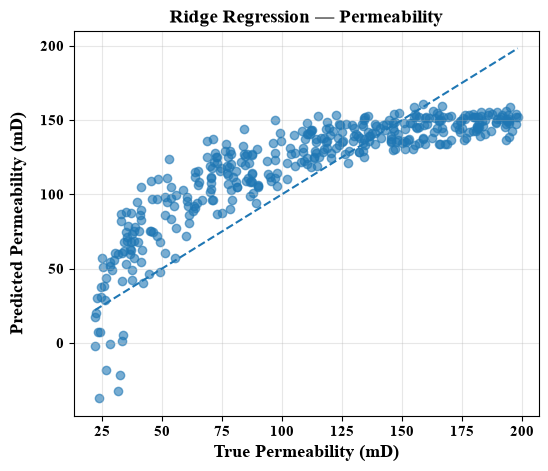

In [33]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test["k_mD"], y_test_pred_ridge[:, 0], alpha=0.6)

ax.plot([y_test["k_mD"].min(), y_test["k_mD"].max()], [y_test["k_mD"].min(), y_test["k_mD"].max()], "--")

ax.set_xlabel("True Permeability (mD)", fontweight="bold", fontsize=13)

ax.set_ylabel("Predicted Permeability (mD)", fontweight="bold", fontsize=13, labelpad=10)

ax.set_title("Ridge Regression — Permeability", fontweight="bold", fontsize=14)

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Ridge Regression_Permeability Parity Plot.jpeg", dpi=300)

plt.show()

### Cell 19A2: Ridge Regression — Skin Parity Plot

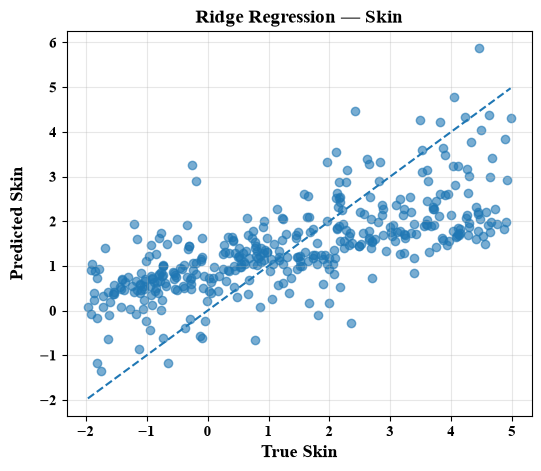

In [34]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test["skin"], y_test_pred_ridge[:, 1], alpha=0.6)

ax.plot([y_test["skin"].min(), y_test["skin"].max()], [y_test["skin"].min(), y_test["skin"].max()], "--")

ax.set_xlabel("True Skin", fontweight="bold", fontsize=13)

ax.set_ylabel("Predicted Skin", fontweight="bold", fontsize=13,labelpad=10)

ax.set_title("Ridge Regression — Skin", fontweight="bold", fontsize=14)

ax.grid(True, which="both", alpha=0.3)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Ridge Regression_Permeability Parity Plot.jpeg", dpi = 300)

plt.show()

## Cell 19B: Ridge Regression Feature Importance Plots

In [35]:
k_ridge_df = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient Magnitude": np.abs(ridge_model.coef_[0]),
    "Feature Importance (Normalized Coefficient)": np.abs(ridge_model.coef_[0])/sum(np.abs(ridge_model.coef_[0]))
})
print("Most important features for permeability:")
print(k_ridge_df.sort_values(
    "Feature Importance (Normalized Coefficient)",
    ascending=False))

k_ridge_df = k_ridge_df.sort_values(
    "Feature Importance (Normalized Coefficient)")

Most important features for permeability:
     Feature  Coefficient Magnitude  \
13     D_3hr              38.371774   
11   D_0.5hr              21.057481   
10   D_0.1hr              17.856811   
12     D_1hr              15.573715   
3    P_0.5hr              15.056686   
14    D_10hr              12.478721   
15    D_30hr               8.146785   
9   D_0.03hr               7.572396   
5      P_3hr               7.405426   
6     P_10hr               6.945455   
4      P_1hr               6.784024   
8   D_0.01hr               5.625899   
7     P_30hr               3.962677   
2    P_0.1hr               2.326453   
0   P_0.01hr               1.971724   
1   P_0.03hr               0.265328   

    Feature Importance (Normalized Coefficient)  
13                                     0.223871  
11                                     0.122855  
10                                     0.104181  
12                                     0.090861  
3                                      0.087

In [36]:
skin_ridge_df = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient Magnitude": np.abs(ridge_model.coef_[1]),
    "Feature Importance (Normalized Coefficient)": np.abs(ridge_model.coef_[1])/sum(np.abs(ridge_model.coef_[1]))
})
print("\nMost important features for skin:")
print(skin_ridge_df.sort_values(
    "Feature Importance (Normalized Coefficient)",
    ascending=False))
skin_ridge_df = skin_ridge_df.sort_values(
    "Feature Importance (Normalized Coefficient)")


Most important features for skin:
     Feature  Coefficient Magnitude  \
13     D_3hr               3.482457   
12     D_1hr               1.767476   
8   D_0.01hr               1.620777   
0   P_0.01hr               1.392394   
15    D_30hr               1.153048   
11   D_0.5hr               0.438472   
9   D_0.03hr               0.423975   
14    D_10hr               0.404501   
4      P_1hr               0.313681   
5      P_3hr               0.286082   
7     P_30hr               0.245310   
10   D_0.1hr               0.145365   
1   P_0.03hr               0.068353   
2    P_0.1hr               0.063518   
3    P_0.5hr               0.057442   
6     P_10hr               0.040155   

    Feature Importance (Normalized Coefficient)  
13                                     0.292570  
12                                     0.148490  
8                                      0.136165  
0                                      0.116978  
15                                     0.096870  
1

### Cell 19B1: Ridge Regression — Permeability Feature Importance Plot

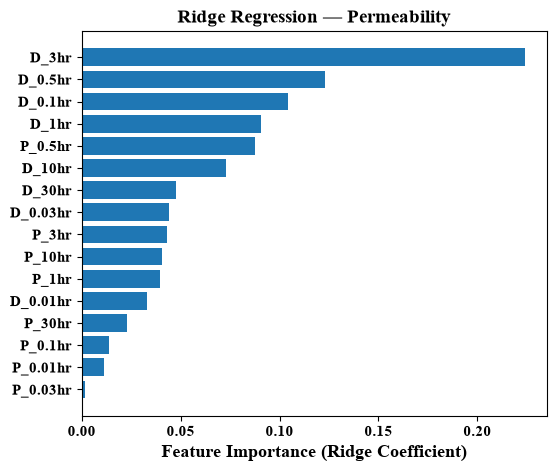

In [37]:
fig,ax = plt.subplots(figsize=(6, 5))

ax.barh(k_ridge_df["Feature"], k_ridge_df["Feature Importance (Normalized Coefficient)"])

ax.set_xlabel("Feature Importance (Ridge Coefficient)", fontweight="bold", fontsize=13)

ax.set_title("Ridge Regression — Permeability", fontweight="bold", fontsize=14)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Ridge Regression_Permeability Feature Importance Plot.jpeg", dpi = 300)

plt.show()

### Cell 19B2: Ridge Regression — Skin Feature Importance Plot

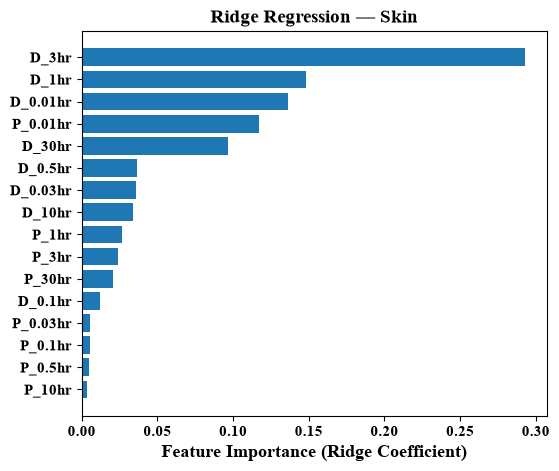

In [38]:
fig,ax = plt.subplots(figsize=(6, 5))

ax.barh(skin_ridge_df["Feature"], skin_ridge_df["Feature Importance (Normalized Coefficient)"])

ax.set_xlabel("Feature Importance (Ridge Coefficient)", fontweight="bold", fontsize=13)

ax.set_title("Ridge Regression — Skin", fontweight="bold", fontsize=14)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Ridge Regression_Skin Feature Importance Plot.jpeg", dpi = 300)

plt.show()

# Cell 20: Random Forest Feature Importance

## Cell 20A: Random Forest Overall Feature Importance

In [39]:
rf_importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

rf_importance_df = rf_importance_df.sort_values(
    "Importance",
    ascending=False
)

rf_importance_df

,Feature,Importance
11,D_0.5hr,0.699859
12,D_1hr,0.214096
5,P_3hr,0.035080
13,D_3hr,0.015020
4,P_1hr,0.012729
6,P_10hr,0.004657
7,P_30hr,0.003291
14,D_10hr,0.003014
15,D_30hr,0.002187
10,D_0.1hr,0.002120


## Cell 20B: Random Forest Permeability Feature Importance

In [40]:
k_importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_k.feature_importances_
})

print(k_importance_df.sort_values(
    "Importance",
    ascending=False))

k_importance_df = k_importance_df.sort_values(
    "Importance")

     Feature  Importance
11   D_0.5hr    0.700458
12     D_1hr    0.214687
5      P_3hr    0.034837
13     D_3hr    0.014840
4      P_1hr    0.012581
6     P_10hr    0.004506
7     P_30hr    0.003451
14    D_10hr    0.003244
15    D_30hr    0.002136
10   D_0.1hr    0.001938
0   P_0.01hr    0.001907
2    P_0.1hr    0.001483
8   D_0.01hr    0.001119
1   P_0.03hr    0.001092
3    P_0.5hr    0.000999
9   D_0.03hr    0.000723


## Cell 20C: Random Forest Skin Feature Importance

In [41]:
skin_importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_skin.feature_importances_ 
})

print(skin_importance_df.sort_values(
    "Importance",
    ascending=False))

skin_importance_df = skin_importance_df.sort_values(
    "Importance")


     Feature  Importance
9   D_0.03hr    0.218411
2    P_0.1hr    0.192873
12     D_1hr    0.118516
10   D_0.1hr    0.062545
15    D_30hr    0.051272
11   D_0.5hr    0.049055
7     P_30hr    0.045734
13     D_3hr    0.045081
8   D_0.01hr    0.038304
14    D_10hr    0.032807
1   P_0.03hr    0.032466
3    P_0.5hr    0.029466
4      P_1hr    0.024922
5      P_3hr    0.024101
6     P_10hr    0.017325
0   P_0.01hr    0.017121


## Cell 20D: Random Forest — Overall Feature Importance Plot

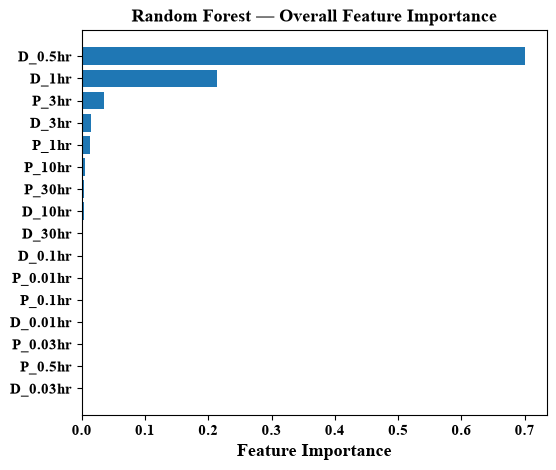

In [42]:
rf_plot = rf_importance_df.sort_values("Importance")

fig,ax = plt.subplots(figsize=(6, 5))

ax.barh(rf_plot["Feature"], rf_plot["Importance"])

ax.set_xlabel("Feature Importance", fontweight="bold", fontsize=13)

ax.set_title("Random Forest — Overall Feature Importance", fontweight="bold", fontsize=13)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Random Forest_Overall Feature Importance Plot.jpeg", dpi = 300)

plt.show()

## Cell 20E: Random Forest — Permeability Feature Importance Plot

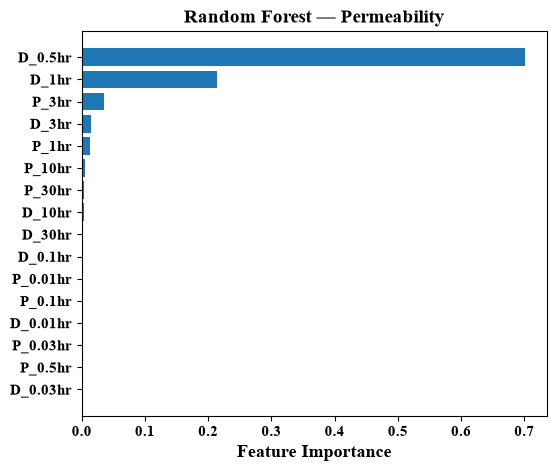

In [43]:
fig,ax = plt.subplots(figsize=(6, 5))

ax.barh(k_importance_df["Feature"], k_importance_df["Importance"])

ax.set_xlabel("Feature Importance", fontweight="bold", fontsize=13)

ax.set_title("Random Forest — Permeability", fontweight="bold", fontsize=14)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Random Forest_Permeability Feature Importance Plot.jpeg", dpi = 300)

plt.show()

## Cell 20F: Random Forest — Skin Feature Importance Plot

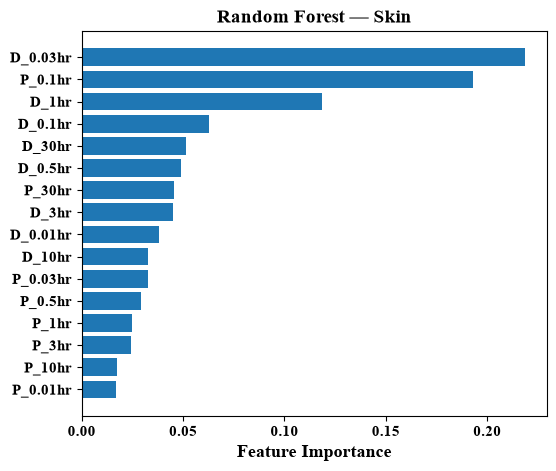

In [44]:
fig,ax = plt.subplots(figsize=(6, 5))

ax.barh(skin_importance_df["Feature"], skin_importance_df["Importance"])

ax.set_xlabel("Feature Importance", fontweight="bold", fontsize=13)

ax.set_title("Random Forest — Skin", fontweight="bold", fontsize=14)

ax.tick_params(axis='both', labelsize=11)

fig.savefig("Random Forest_Skin Feature Importance Plot.jpeg", dpi = 300)

plt.show()

# Cell 21: Compare All Three Models

## Cell 21A: Compare All Three Models (combined RF model for permeability and skin)

In [45]:
results = pd.DataFrame({
    "Model": [
        "Ridge",
        "Random Forest",
        "Gradient Boosting"
    ],
    "k_MAE": [
        mean_absolute_error(y_test["k_mD"], y_test_pred_ridge[:, 0]),
        mean_absolute_error(y_test["k_mD"], y_test_pred_rf[:, 0]),
        mean_absolute_error(y_test["k_mD"], y_test_pred_gb[:, 0])
    ],
    "k_R2": [
        r2_score(y_test["k_mD"], y_test_pred_ridge[:, 0]),
        r2_score(y_test["k_mD"], y_test_pred_rf[:, 0]),
        r2_score(y_test["k_mD"], y_test_pred_gb[:, 0])
    ],
    "Skin_MAE": [
        mean_absolute_error(y_test["skin"], y_test_pred_ridge[:, 1]),
        mean_absolute_error(y_test["skin"], y_test_pred_rf[:, 1]),
        mean_absolute_error(y_test["skin"], y_test_pred_gb[:, 1])
    ],
    "Skin_R2": [
        r2_score(y_test["skin"], y_test_pred_ridge[:, 1]),
        r2_score(y_test["skin"], y_test_pred_rf[:, 1]),
        r2_score(y_test["skin"], y_test_pred_gb[:, 1])
    ]
})

results

,Model,k_MAE,k_R2,Skin_MAE,Skin_R2
0,Ridge,25.854755,0.659948,1.193124,0.460466
1,Random Forest,8.081320,0.953659,0.873677,0.700736
2,Gradient Boosting,7.589218,0.960736,0.775599,0.728921


## Cell 21B: Compare All Three Models with separate RF models for permeability and skin

In [46]:
results_new = pd.DataFrame({
    "Model": [
        "Ridge",
        "Random Forest",
        "Gradient Boosting"
    ],
    "k_MAE": [
        mean_absolute_error(y_test["k_mD"], y_test_pred_ridge[:, 0]),
        mean_absolute_error(y_test["k_mD"], k_test_pred_rf),
        mean_absolute_error(y_test["k_mD"], y_test_pred_gb[:, 0])
    ],
    "k_R2": [
        r2_score(y_test["k_mD"], y_test_pred_ridge[:, 0]),
        r2_score(y_test["k_mD"], k_test_pred_rf),
        r2_score(y_test["k_mD"], y_test_pred_gb[:, 0])
    ],
    "Skin_MAE": [
        mean_absolute_error(y_test["skin"], y_test_pred_ridge[:, 1]),
        mean_absolute_error(y_test["skin"], skin_test_pred_rf),
        mean_absolute_error(y_test["skin"], y_test_pred_gb[:, 1])
    ],
    "Skin_R2": [
        r2_score(y_test["skin"], y_test_pred_ridge[:, 1]),
        r2_score(y_test["skin"], skin_test_pred_rf),
        r2_score(y_test["skin"], y_test_pred_gb[:, 1])
    ]
})

results_new


,Model,k_MAE,k_R2,Skin_MAE,Skin_R2
0,Ridge,25.854755,0.659948,1.193124,0.460466
1,Random Forest,7.998526,0.954632,0.842919,0.705029
2,Gradient Boosting,7.589218,0.960736,0.775599,0.728921


# Week 3 — Controlled Experiments

The baseline implementation is complete. The remaining analyses are controlled experiments designed to answer three questions:

1. **Training-size sensitivity:** Does adding independent training data improve permeability and skin prediction?
2. **Feature representation:** Do simple physics-informed summary features add information beyond the 16 fixed-time pressure/derivative features?
3. **Skin-error diagnosis:** Where does the remaining skin error occur, and how is it related to skin magnitude, wellbore storage, boundary type, and permeability?

Model hyperparameter tuning is intentionally deferred. The goal here is to understand the data and the physics before increasing model complexity.


# Experiment 1 — Initial Cross-Validation Learning-Curve Diagnosis

Use only the original 100-case training set to determine whether the baseline Gradient Boosting model appears data-limited before generating an independent development dataset.


# Cell 22 — Set up the learning-curve experiment

In [47]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_sizes = [0.25, 0.50, 0.75, 1.0]

# Cell 23 — Learning curve for permeability

In [48]:
X_dev = X_train
y_dev_k = y_train["k_mD"]

train_sizes_k, train_scores_k, val_scores_k = learning_curve(
    estimator=clone(gb_model.estimators_[0]),
    X=X_dev,
    y=y_dev_k,
    train_sizes=train_sizes,
    cv=cv,
    scoring="r2",
    shuffle=True,
    random_state=42,
    n_jobs=-1
)

print("Training sizes:", train_sizes_k)

print(
    "Mean training R²:",
    train_scores_k.mean(axis=1)
)

print(
    "Mean validation R²:",
    val_scores_k.mean(axis=1)
)

Training sizes: [20 40 60 80]
Mean training R²: [1.         0.99999622 0.99994836 0.99984998]
Mean validation R²: [0.86897433 0.91460717 0.92408883 0.91359248]


# Cell 24 — Plot it

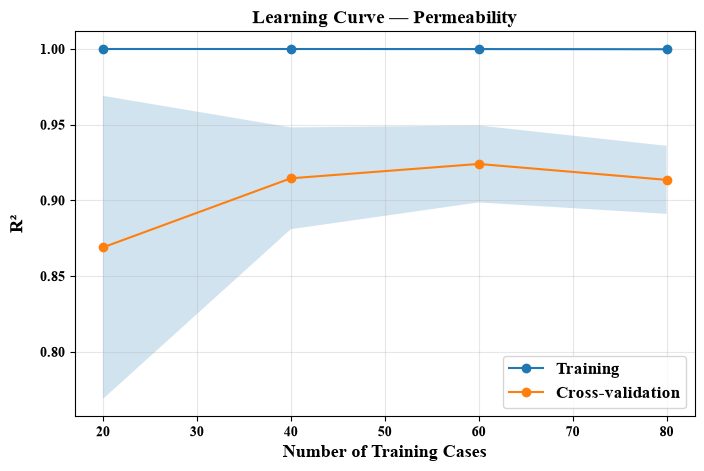

In [49]:
train_mean_k = train_scores_k.mean(axis=1)
train_std_k = train_scores_k.std(axis=1)

val_mean_k = val_scores_k.mean(axis=1)
val_std_k = val_scores_k.std(axis=1)

fig,ax = plt.subplots(figsize=(8, 5))

ax.plot(
    train_sizes_k,
    train_mean_k,
    marker="o",
    label="Training"
)

ax.plot(
    train_sizes_k,
    val_mean_k,
    marker="o",
    label="Cross-validation"
)

ax.fill_between(
    train_sizes_k,
    val_mean_k - val_std_k,
    val_mean_k + val_std_k,
    alpha=0.2
)

ax.set_xlabel("Number of Training Cases", fontweight="bold", fontsize=13)
ax.set_ylabel("R²", fontweight="bold", fontsize=13, labelpad=10)
ax.set_title("Learning Curve — Permeability", fontweight="bold", fontsize=14)
ax.legend()
ax.grid(True, which="both", alpha=0.3)

fig.savefig("Gradient Boosting_Learning Curve Permeability Plot.jpeg", dpi = 300)

plt.show()

# Cell 25 — Learning curve for skin

In [50]:
y_dev_skin = y_train["skin"]

train_sizes_skin, train_scores_skin, val_scores_skin = learning_curve(
    estimator=clone(gb_model.estimators_[1]),
    X=X_dev,
    y=y_dev_skin,
    train_sizes=train_sizes,
    cv=cv,
    scoring="r2",
    shuffle=True,
    random_state=42,
    n_jobs=-1
)

print("Training sizes:", train_sizes_skin)

print(
    "Mean training R²:",
    train_scores_skin.mean(axis=1)
)

print(
    "Mean validation R²:",
    val_scores_skin.mean(axis=1)
)

Training sizes: [20 40 60 80]
Mean training R²: [0.99999355 0.99969406 0.99934574 0.9977742 ]
Mean validation R²: [-0.04786664  0.34653321  0.48069674  0.52399925]


# Cell 26 — Plot skin learning curve

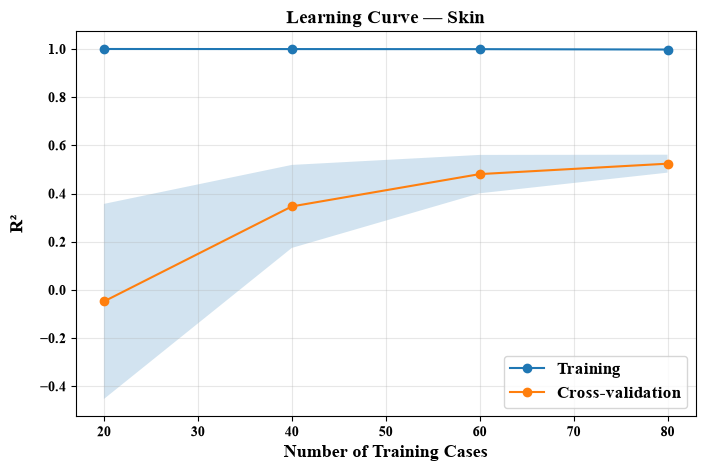

In [51]:
train_mean_skin = train_scores_skin.mean(axis=1)
train_std_skin = train_scores_skin.std(axis=1)

val_mean_skin = val_scores_skin.mean(axis=1)
val_std_skin = val_scores_skin.std(axis=1)

fig,ax = plt.subplots(figsize=(8, 5))

ax.plot(
    train_sizes_skin,
    train_mean_skin,
    marker="o",
    label="Training"
)

ax.plot(
    train_sizes_skin,
    val_mean_skin,
    marker="o",
    label="Cross-validation"
)

ax.fill_between(
    train_sizes_skin,
    val_mean_skin - val_std_skin,
    val_mean_skin + val_std_skin,
    alpha=0.2
)

ax.set_xlabel("Number of Training Cases", fontweight="bold", fontsize=13)
ax.set_ylabel("R²", fontweight="bold", fontsize=13, labelpad=10)
ax.set_title("Learning Curve — Skin", fontweight="bold", fontsize=14)
ax.legend()
ax.grid(True, which="both", alpha=0.3)

fig.savefig("Gradient Boosting_Learning Curve Skin Plot.jpeg", dpi = 300)

plt.show()

## Experiment 1A — Extended Training-Size Study
### Independent Synthetic Development Dataset

# Cell 27 — Generate 500 new independent parameter cases

In [52]:
rng_exp = np.random.default_rng(2026)

n_exp_cases = 500

experimental_parameters = pd.DataFrame({
    "case_id": np.arange(500, 500 + n_exp_cases),

    "k_mD": rng_exp.uniform(20, 200, n_exp_cases),
    "skin": rng_exp.uniform(-2, 5, n_exp_cases),
    "C_bbl_per_psi": rng_exp.uniform(0.0025, 0.020, n_exp_cases),
    "re_ft": rng_exp.uniform(125, 1000, n_exp_cases),

    "boundary_type": rng_exp.choice(
        ["no_flow", "constant_pressure"],
        size=n_exp_cases
    )
})

experimental_parameters.head()

,case_id,k_mD,skin,C_bbl_per_psi,re_ft,boundary_type
0,500,52.208266,4.098453,0.016561,325.573462,no_flow
1,501,135.184370,-0.134496,0.004189,639.335760,constant_pressure
2,502,104.108312,4.258215,0.014789,533.076108,constant_pressure
3,503,86.690095,0.142604,0.012591,848.016765,constant_pressure
4,504,83.885120,-1.599201,0.014913,835.742385,constant_pressure


# Cell 28 — Check the new parameter population

In [53]:
print("Boundary counts:")
print(experimental_parameters["boundary_type"].value_counts())

print("\nParameter statistics:")
display(
    experimental_parameters[
        ["k_mD", "skin", "C_bbl_per_psi", "re_ft"]
    ].describe()
)

Boundary counts:
boundary_type
no_flow              252
constant_pressure    248
Name: count, dtype: int64

Parameter statistics:


,k_mD,skin,C_bbl_per_psi,re_ft
count,500.000000,500.000000,500.000000,500.000000
mean,110.035731,1.804628,0.011295,548.563842
std,50.747803,2.010883,0.005124,251.529185
min,20.324424,-1.990099,0.002558,126.536300
25%,67.892602,0.100854,0.006868,325.300681
50%,109.612233,2.030191,0.011342,529.649239
75%,153.436692,3.499589,0.015743,762.141960
max,199.898564,4.998483,0.019922,999.467358


# Cell 29 — Imports, constants, time grid, and dimensionless conversion

In [54]:
# Same fixed physical parameters used for Dataset V1
phi = 0.20
mu = 1.0
ct = 1.5e-5
rw = 0.25
h = 50.0
q = 500.0
B = 1.2

# EXACT same time grid as Dataset V1
n_time = 290
time_dataset = np.logspace(-4, 2, n_time)


def calculate_dimensionless_parameters(
    time_hr, k, phi, mu, ct, rw, h, C, re
):
    tD = 0.0002637 * k * time_hr / (
        phi * mu * ct * rw**2
    )

    CD = 0.8936 * C / (
        phi * ct * h * rw**2
    )

    reD = re / rw

    return tD, CD, reD

# Cell 30 — Bourdet derivative

In [55]:
def bourdet_derivative(pressure, time):

    pressure = np.asarray(pressure, dtype=float)
    time = np.asarray(time, dtype=float)

    if len(pressure) != len(time):
        raise ValueError(
            "pressure and time must have the same length"
        )

    if np.any(time <= 0):
        raise ValueError(
            "time values must be positive"
        )

    ln_time = np.log(time)

    derivative = np.full(
        len(pressure),
        np.nan
    )

    for i in range(1, len(pressure) - 1):

        dx_left = (
            ln_time[i] - ln_time[i - 1]
        )

        dx_right = (
            ln_time[i + 1] - ln_time[i]
        )

        slope_left = (
            pressure[i] - pressure[i - 1]
        ) / dx_left

        slope_right = (
            pressure[i + 1] - pressure[i]
        ) / dx_right

        derivative[i] = (
            slope_left
            * dx_right
            / (dx_left + dx_right)
            +
            slope_right
            * dx_left
            / (dx_left + dx_right)
        )

    return derivative

# Cell 31 — Fast constant-pressure and no-flow boundary solutions

In [56]:
def pD_constant_pressure_fast(u, reD):
    u = np.asarray(u, dtype=float)

    x = np.sqrt(u)
    xe = reD * x

    I0_x = iv(0, x)
    K0_x = kv(0, x)

    I1_x = iv(1, x)
    K1_x = kv(1, x)

    # Stable representation of K0(reD*x) / I0(reD*x)
    scaled_ratio = kve(0, xe) / ive(0, xe)
    R = scaled_ratio * np.exp(-2.0 * xe)

    numerator = K0_x - R * I0_x
    denominator = x * (K1_x + R * I1_x)

    return (1.0 / u) * numerator / denominator


def pWD_constant_pressure_fast(u, reD, CD):
    pD_bar = pD_constant_pressure_fast(u, reD)

    # Add wellbore storage in Laplace space
    return 1.0 / (
        1.0 / pD_bar + u**2 * CD
    )


def pD_no_flow_fast(u, reD):
    u = np.asarray(u, dtype=float)

    x = np.sqrt(u)
    xe = reD * x

    I0_x = iv(0, x)
    K0_x = kv(0, x)

    I1_x = iv(1, x)
    K1_x = kv(1, x)

    # Stable representation of K1(reD*x) / I1(reD*x)
    scaled_ratio = kve(1, xe) / ive(1, xe)
    R = scaled_ratio * np.exp(-2.0 * xe)

    numerator = K0_x + R * I0_x
    denominator = x * (K1_x - R * I1_x)

    return (1.0 / u) * numerator / denominator


def pWD_no_flow_fast(u, reD, CD):
    pD_bar = pD_no_flow_fast(u, reD)

    # Add wellbore storage in Laplace space
    return 1.0 / (
        1.0 / pD_bar + u**2 * CD
    )

# Cell 32 — Stehfest weights and fast inverse Laplace functions

In [57]:
def stehfest_weights(N=16):

    if N % 2 != 0:
        raise ValueError("N must be even")

    M = N // 2
    V = []

    for k in range(1, N + 1):

        total = mp.mpf("0")

        j_min = (k + 1) // 2
        j_max = min(k, M)

        for j in range(j_min, j_max + 1):

            numerator = (
                mp.power(j, M)
                * mp.factorial(2 * j)
            )

            denominator = (
                mp.factorial(M - j)
                * mp.factorial(j)
                * mp.factorial(j - 1)
                * mp.factorial(k - j)
                * mp.factorial(2 * j - k)
            )

            total += numerator / denominator

        V.append(
            mp.power(-1, k + M) * total
        )

    return V


V16 = stehfest_weights(16)


def inverse_constant_pressure_fast(
    tD, CD, skin, reD, weights=V16
):

    # Effective-radius representation of skin
    factor = np.exp(2.0 * skin)

    tD_eff = np.asarray(tD, dtype=float) * factor
    CD_eff = CD * factor
    reD_eff = reD * np.exp(skin)

    j = np.arange(
        1, len(weights) + 1,
        dtype=float
    )

    V = np.array(
        [float(v) for v in weights]
    )

    ln2 = np.log(2.0)

    u = (
        j[None, :] * ln2
        / tD_eff[:, None]
    )

    F = pWD_constant_pressure_fast(
        u,
        reD=reD_eff,
        CD=CD_eff
    )

    return (
        ln2 / tD_eff
        * np.sum(F * V[None, :], axis=1)
    )


def inverse_no_flow_fast(
    tD, CD, skin, reD, weights=V16
):

    # Effective-radius representation of skin
    factor = np.exp(2.0 * skin)

    tD_eff = np.asarray(tD, dtype=float) * factor
    CD_eff = CD * factor
    reD_eff = reD * np.exp(skin)

    j = np.arange(
        1, len(weights) + 1,
        dtype=float
    )

    V = np.array(
        [float(v) for v in weights]
    )

    ln2 = np.log(2.0)

    u = (
        j[None, :] * ln2
        / tD_eff[:, None]
    )

    F = pWD_no_flow_fast(
        u,
        reD=reD_eff,
        CD=CD_eff
    )

    return (
        ln2 / tD_eff
        * np.sum(F * V[None, :], axis=1)
    )

# Cell 33 — Unified fast case generator

In [58]:
def generate_one_case_fast(row):

    # Convert dimensional parameters to dimensionless variables
    tD, CD, reD = calculate_dimensionless_parameters(
        time_hr=time_dataset,
        k=row["k_mD"],
        phi=phi,
        mu=mu,
        ct=ct,
        rw=rw,
        h=h,
        C=row["C_bbl_per_psi"],
        re=row["re_ft"]
    )

    # Solve according to outer-boundary condition
    if row["boundary_type"] == "no_flow":

        pWD = inverse_no_flow_fast(
            tD=tD,
            CD=CD,
            skin=row["skin"],
            reD=reD
        )

    elif row["boundary_type"] == "constant_pressure":

        pWD = inverse_constant_pressure_fast(
            tD=tD,
            CD=CD,
            skin=row["skin"],
            reD=reD
        )

    else:
        raise ValueError("Unknown boundary type")

    # Convert dimensionless pressure to dimensional pressure drop
    pressure_factor = (
        141.2 * q * mu * B
        / (row["k_mD"] * h)
    )

    delta_p = pressure_factor * pWD

    # Clean Bourdet derivative
    derivative = bourdet_derivative(
        delta_p,
        time_dataset
    )

    return {
        "case_id": int(row["case_id"]),
        "boundary_type": row["boundary_type"],
        "k_mD": float(row["k_mD"]),
        "skin": float(row["skin"]),
        "C_bbl_per_psi": float(row["C_bbl_per_psi"]),
        "re_ft": float(row["re_ft"]),
        "pWD": pWD,
        "delta_p_psi": delta_p,
        "derivative_psi": derivative,
        "tD": tD,
        "CD": CD,
        "reD": reD
    }

# Cell 34 — Test only case 500

In [59]:
test_row = experimental_parameters.iloc[0]

test_case = generate_one_case_fast(test_row)

print("Case ID:", test_case["case_id"])
print("Boundary:", test_case["boundary_type"])
print("k:", test_case["k_mD"])
print("Skin:", test_case["skin"])
print("C:", test_case["C_bbl_per_psi"])
print("re:", test_case["re_ft"])

print("\nNumber of time points:",
      len(test_case["delta_p_psi"]))

print("Pressure finite:",
      np.all(np.isfinite(test_case["delta_p_psi"])))

print("Pressure positive:",
      np.all(test_case["delta_p_psi"] > 0))

print("Interior derivative finite:",
      np.all(np.isfinite(test_case["derivative_psi"][1:-1])))

Case ID: 500
Boundary: no_flow
k: 52.20826646157851
Skin: 4.098453021418875
C: 0.016561366503913467
re: 325.5734623550482

Number of time points: 290
Pressure finite: True
Pressure positive: True
Interior derivative finite: True


# Cell 35 — Generate cases 500–999

In [60]:
start_time = time.time()

experimental_clean_cases = []

for _, row in experimental_parameters.iterrows():
    case = generate_one_case_fast(row)
    experimental_clean_cases.append(case)

elapsed_time = time.time() - start_time

print("Generated cases:", len(experimental_clean_cases))
print("Points per case:", len(time_dataset))
print("Total transient points:",
      len(experimental_clean_cases) * len(time_dataset))
print(f"Runtime: {elapsed_time:.2f} seconds")

Generated cases: 500
Points per case: 290
Total transient points: 145000
Runtime: 2.94 seconds


# Cell 36 — Quality-control all 500 new cases

In [61]:
n_nonfinite_pressure = 0
n_nonpositive_pressure = 0
n_nonfinite_derivative = 0

for case in experimental_clean_cases:

    pressure = case["delta_p_psi"]
    derivative = case["derivative_psi"]

    if not np.all(np.isfinite(pressure)):
        n_nonfinite_pressure += 1

    if np.any(pressure <= 0):
        n_nonpositive_pressure += 1

    # First and last Bourdet points are intentionally NaN
    if not np.all(np.isfinite(derivative[1:-1])):
        n_nonfinite_derivative += 1


print("Cases with non-finite pressure:",
      n_nonfinite_pressure)

print("Cases with non-positive pressure:",
      n_nonpositive_pressure)

print("Cases with non-finite interior derivative:",
      n_nonfinite_derivative)

Cases with non-finite pressure: 0
Cases with non-positive pressure: 0
Cases with non-finite interior derivative: 0


In [62]:
negative_derivative_info = []

for case in experimental_clean_cases:
    d = case["derivative_psi"]

    # Ignore first/last NaN points
    d_interior = d[1:-1]

    if np.any(d_interior < 0):
        min_idx_local = np.argmin(d_interior)
        min_idx = min_idx_local + 1

        negative_derivative_info.append({
            "case_id": case["case_id"],
            "boundary_type": case["boundary_type"],
            "min_derivative": d[min_idx],
            "time_hr": time_dataset[min_idx]
        })

negative_df = pd.DataFrame(negative_derivative_info)

print("Cases with negative derivative:", len(negative_df))

if len(negative_df) > 0:
    print("\nMost negative derivative:")
    display(
        negative_df.sort_values("min_derivative").head(10)
    )

Cases with negative derivative: 115

Most negative derivative:


,case_id,boundary_type,min_derivative,time_hr
106,968,constant_pressure,-0.007292,51.208560
96,903,constant_pressure,-0.002658,82.595240
111,989,constant_pressure,-0.002434,36.644925
91,875,constant_pressure,-0.002251,20.648043
38,670,constant_pressure,-0.002078,15.499276
56,719,constant_pressure,-0.001785,42.295833
30,634,constant_pressure,-0.001773,59.105283
17,567,constant_pressure,-0.001748,21.659087
87,847,constant_pressure,-0.001662,17.054300
26,622,constant_pressure,-0.001604,16.258208


# Cell 37 — Add pressure noise and smooth

In [63]:
sigma_abs = 0.02
relative_fraction = 0.001

experimental_observed_cases = []

for case in experimental_clean_cases:

    p_clean = case["delta_p_psi"]

    # Reproducible, unique noise realization for each new case
    rng = np.random.default_rng(
        1000 + case["case_id"]
    )

    # Absolute + relative pressure-noise model
    sigma_pressure = np.sqrt(
        sigma_abs**2
        + (relative_fraction * p_clean)**2
    )

    p_noisy = (
        p_clean
        + rng.normal(
            0.0,
            sigma_pressure
        )
    )

    # Same smoothing used for Dataset V1
    p_smooth = savgol_filter(
        p_noisy,
        window_length=21,
        polyorder=2
    )

    # Derivative is calculated AFTER smoothing pressure
    d_observed = bourdet_derivative(
        p_smooth,
        time_dataset
    )

    experimental_observed_cases.append({
        "case_id": case["case_id"],
        "boundary_type": case["boundary_type"],
        "k_mD": case["k_mD"],
        "skin": case["skin"],
        "C_bbl_per_psi": case["C_bbl_per_psi"],
        "re_ft": case["re_ft"],

        "pressure_clean": p_clean.copy(),
        "pressure_noisy": p_noisy,
        "pressure_smoothed": p_smooth,

        "derivative_clean":
            case["derivative_psi"].copy(),

        "derivative_observed":
            d_observed,

        "noise_sigma":
            sigma_pressure
    })

print(
    "Processed cases:",
    len(experimental_observed_cases)
)

Processed cases: 500


# Cell 38 — QC the observed data

In [64]:
bad_pressure = 0
bad_derivative = 0

for case in experimental_observed_cases:

    if not np.all(
        np.isfinite(case["pressure_smoothed"])
    ):
        bad_pressure += 1

    # Endpoints intentionally NaN for Bourdet
    if not np.all(
        np.isfinite(
            case["derivative_observed"][1:-1]
        )
    ):
        bad_derivative += 1


print(
    "Non-finite smoothed pressure cases:",
    bad_pressure
)

print(
    "Non-finite interior derivative cases:",
    bad_derivative
)

Non-finite smoothed pressure cases: 0
Non-finite interior derivative cases: 0


# Cell 39 — Define the same feature times and interpolation

In [65]:
feature_times = np.array([
    0.01,
    0.03,
    0.1,
    0.5,
    1.0,
    3.0,
    10.0,
    30.0
])


def interpolate_log_time(time, values, target_times):
    return np.interp(
        np.log10(target_times),
        np.log10(time),
        values
    )

# Cell 40 — Extract the 16 features

In [66]:
experimental_feature_rows = []

for case in experimental_observed_cases:

    P_features = interpolate_log_time(
        time_dataset,
        case["pressure_smoothed"],
        feature_times
    )

    D_features = interpolate_log_time(
        time_dataset,
        case["derivative_observed"],
        feature_times
    )

    row = {
        "case_id": case["case_id"]
    }

    # 8 pressure features
    for t, value in zip(feature_times, P_features):
        row[f"P_{t:g}hr"] = value

    # 8 derivative features
    for t, value in zip(feature_times, D_features):
        row[f"D_{t:g}hr"] = value

    # Targets
    row["k_mD"] = case["k_mD"]
    row["skin"] = case["skin"]

    experimental_feature_rows.append(row)


experimental_df = pd.DataFrame(
    experimental_feature_rows
)

print("Shape:", experimental_df.shape)
experimental_df.head()

Shape: (500, 19)


,case_id,P_0.01hr,P_0.03hr,P_0.1hr,P_0.5hr,P_1hr,P_3hr,P_10hr,P_30hr,D_0.01hr,D_0.03hr,D_0.1hr,D_0.5hr,D_1hr,D_3hr,D_10hr,D_30hr,k_mD,skin
0,500,14.608957,41.406552,115.487434,276.997015,315.916579,342.902274,368.170123,424.345290,14.221774,37.863995,88.340015,78.577185,36.247413,18.269527,29.186790,84.642088,52.208266,4.098453
1,501,32.571647,51.165728,63.548585,74.884319,79.389244,86.420724,93.699204,96.547504,18.223897,13.868190,7.973540,6.528074,6.300232,6.351157,5.246288,0.663753,135.184370,-0.134496
2,502,15.811674,42.183390,99.507840,161.874391,170.793947,180.932432,190.590429,194.063573,14.746274,35.074555,55.658901,16.395294,10.269354,8.679863,6.652328,1.160437,104.108312,4.258215
3,503,17.182838,41.774161,82.080676,115.603492,123.792638,135.477417,147.527413,157.706280,15.108098,29.782291,31.648481,12.764391,11.466549,10.154863,10.237518,7.524892,86.690095,0.142604
4,504,13.440171,31.049103,58.094383,84.498877,92.625390,104.471903,116.959495,127.443845,11.333470,20.610809,21.522328,12.643675,11.271705,10.633859,10.358176,7.315542,83.885120,-1.599201


In [67]:
experimental_feature_columns = [
    col for col in experimental_df.columns
    if col.startswith("P_") or col.startswith("D_")
]

print("Number of features:",
      len(experimental_feature_columns))

print("\nNew features:")
print(experimental_feature_columns)

print("\nOriginal features:")
print(feature_columns)

print(
    "\nFeature sets identical:",
    experimental_feature_columns == feature_columns
)

print(
    "Any missing values:",
    experimental_df[
        experimental_feature_columns
    ].isna().any().any()
)

Number of features: 16

New features:
['P_0.01hr', 'P_0.03hr', 'P_0.1hr', 'P_0.5hr', 'P_1hr', 'P_3hr', 'P_10hr', 'P_30hr', 'D_0.01hr', 'D_0.03hr', 'D_0.1hr', 'D_0.5hr', 'D_1hr', 'D_3hr', 'D_10hr', 'D_30hr']

Original features:
['P_0.01hr', 'P_0.03hr', 'P_0.1hr', 'P_0.5hr', 'P_1hr', 'P_3hr', 'P_10hr', 'P_30hr', 'D_0.01hr', 'D_0.03hr', 'D_0.1hr', 'D_0.5hr', 'D_1hr', 'D_3hr', 'D_10hr', 'D_30hr']

Feature sets identical: True
Any missing values: False


# Cell 41 — Create nested random training sets

In [68]:
train_sizes_exp = [50, 100, 200, 300, 400, 500]
n_repeats = 10

nested_training_ids = {}

for repeat in range(n_repeats):

    rng = np.random.default_rng(3000 + repeat)

    # Separate the two boundary types and make writable copies
    noflow_ids = experimental_parameters.loc[
        experimental_parameters["boundary_type"] == "no_flow",
        "case_id"
    ].to_numpy().copy()

    cp_ids = experimental_parameters.loc[
        experimental_parameters["boundary_type"] == "constant_pressure",
        "case_id"
    ].to_numpy().copy()

    # Independently shuffle each boundary group
    rng.shuffle(noflow_ids)
    rng.shuffle(cp_ids)

    nested_training_ids[repeat] = {}

    for N in train_sizes_exp:

        if N < 500:

            # Equal representation of the two boundary types
            n_nf = N // 2
            n_cp = N - n_nf

            selected_ids = np.concatenate([
                noflow_ids[:n_nf],
                cp_ids[:n_cp]
            ])

        else:

            # At N=500 use every V2 case
            selected_ids = experimental_parameters[
                "case_id"
            ].to_numpy().copy()

        nested_training_ids[repeat][N] = selected_ids

# Cell 42 — Verify the sampling

In [69]:
for N in train_sizes_exp:

    ids = nested_training_ids[0][N]

    subset = experimental_parameters[
        experimental_parameters["case_id"].isin(ids)
    ]

    counts = subset["boundary_type"].value_counts()

    print(
        f"N={N}:",
        dict(counts)
    )


# Check nesting for repeat 0
print("\nNesting checks:")

for small, large in zip(
    train_sizes_exp[:-1],
    train_sizes_exp[1:]
):

    small_set = set(
        nested_training_ids[0][small]
    )

    large_set = set(
        nested_training_ids[0][large]
    )

    print(
        f"{small} inside {large}:",
        small_set.issubset(large_set)
    )

N=50: {'no_flow': np.int64(25), 'constant_pressure': np.int64(25)}
N=100: {'no_flow': np.int64(50), 'constant_pressure': np.int64(50)}
N=200: {'no_flow': np.int64(100), 'constant_pressure': np.int64(100)}
N=300: {'no_flow': np.int64(150), 'constant_pressure': np.int64(150)}
N=400: {'no_flow': np.int64(200), 'constant_pressure': np.int64(200)}
N=500: {'no_flow': np.int64(252), 'constant_pressure': np.int64(248)}

Nesting checks:
50 inside 100: True
100 inside 200: True
200 inside 300: True
300 inside 400: True
400 inside 500: True


# Cell 43 — Train GB for each training size

In [70]:
experiment_results = []

# Frozen original V1 test set
X_test_exp = test_df[feature_columns]
y_test_exp = test_df[target_columns]

for N in train_sizes_exp:

    # 10 subsets for N < 500, only one for N = 500
    repeats = range(n_repeats) if N < 500 else range(1)

    for repeat in repeats:

        ids = nested_training_ids[repeat][N]

        train_subset = experimental_df[
            experimental_df["case_id"].isin(ids)
        ]

        X_exp_train = train_subset[feature_columns]
        y_exp_train = train_subset[target_columns]

        # Separate GB model for each target
        model_k = GradientBoostingRegressor(
            random_state=42
        )

        model_skin = GradientBoostingRegressor(
            random_state=42
        )

        model_k.fit(
            X_exp_train,
            y_exp_train["k_mD"]
        )

        model_skin.fit(
            X_exp_train,
            y_exp_train["skin"]
        )

        pred_k = model_k.predict(X_test_exp)
        pred_skin = model_skin.predict(X_test_exp)

        experiment_results.append({
            "N_train": N,
            "repeat": repeat,

            "k_R2": r2_score(
                y_test_exp["k_mD"],
                pred_k
            ),

            "k_MAE": mean_absolute_error(
                y_test_exp["k_mD"],
                pred_k
            ),

            "skin_R2": r2_score(
                y_test_exp["skin"],
                pred_skin
            ),

            "skin_MAE": mean_absolute_error(
                y_test_exp["skin"],
                pred_skin
            )
        })


results_df = pd.DataFrame(experiment_results)

print("Total models per target:",
      len(results_df))

results_df.head()

Total models per target: 51


,N_train,repeat,k_R2,k_MAE,skin_R2,skin_MAE
0,50,0,0.953658,7.589068,0.394937,1.149860
1,50,1,0.859967,9.955666,0.458478,1.137260
2,50,2,0.961110,7.524593,0.520495,1.038819
3,50,3,0.883715,10.873553,0.504474,1.089509
4,50,4,0.840032,10.512013,0.318473,1.202985


# Cell 44 — Summarize the training-size effect

In [71]:
summary_results = (
    results_df
    .groupby("N_train")
    .agg(
        k_R2_mean=("k_R2", "mean"),
        k_R2_std=("k_R2", "std"),
        k_MAE_mean=("k_MAE", "mean"),
        k_MAE_std=("k_MAE", "std"),

        skin_R2_mean=("skin_R2", "mean"),
        skin_R2_std=("skin_R2", "std"),
        skin_MAE_mean=("skin_MAE", "mean"),
        skin_MAE_std=("skin_MAE", "std")
    )
)

summary_results

,k_R2_mean,k_R2_std,k_MAE_mean,k_MAE_std,skin_R2_mean,skin_R2_std,skin_MAE_mean,skin_MAE_std
N_train,,,,,,,,
50,0.899404,0.042042,9.672746,1.274213,0.475933,0.086899,1.085507,0.079424
100,0.944833,0.029627,7.415443,0.887311,0.663915,0.052747,0.855674,0.068411
200,0.971635,0.012699,5.644004,0.553281,0.772787,0.034109,0.693107,0.043437
300,0.981299,0.005968,4.931307,0.320107,0.813324,0.013906,0.624046,0.022964
400,0.984363,0.005814,4.534897,0.281879,0.842147,0.013009,0.573942,0.023989
500,0.987903,NaN,4.191366,NaN,0.869051,NaN,0.527755,NaN


# Cell 45 — Prepare values for plotting

In [72]:
plot_summary = summary_results.reset_index()

N = plot_summary["N_train"].to_numpy()

k_mean = plot_summary["k_R2_mean"].to_numpy()
k_std = plot_summary["k_R2_std"].to_numpy()

skin_mean = plot_summary["skin_R2_mean"].to_numpy()
skin_std = plot_summary["skin_R2_std"].to_numpy()

# Cell 46 — Permeability learning curve

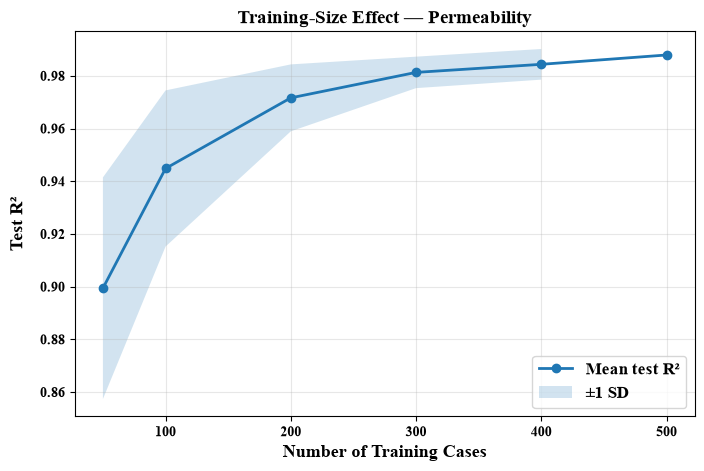

In [73]:
fig,ax = plt.subplots(figsize=(8, 5))

ax.plot(
    N,
    k_mean,
    marker="o",
    linewidth=2,
    label="Mean test R²"
)

# Error bars only where multiple repetitions exist
mask = ~np.isnan(k_std)

ax.fill_between(
    N[mask],
    k_mean[mask] - k_std[mask],
    k_mean[mask] + k_std[mask],
    alpha=0.2,
    label="±1 SD"
)

ax.set_xlabel("Number of Training Cases", fontweight="bold", fontsize=13)
ax.set_ylabel("Test R²", fontweight="bold", fontsize=13, labelpad=10)
ax.set_title("Training-Size Effect — Permeability", fontweight="bold", fontsize=14)
ax.legend()
ax.grid(True, which="both", alpha=0.3)

fig.savefig("Gradient Boosting_Training-Size Effect Permeability Learning Curve Plot.jpeg", dpi = 300)

plt.show()

# Cell 47 — Skin learning curve

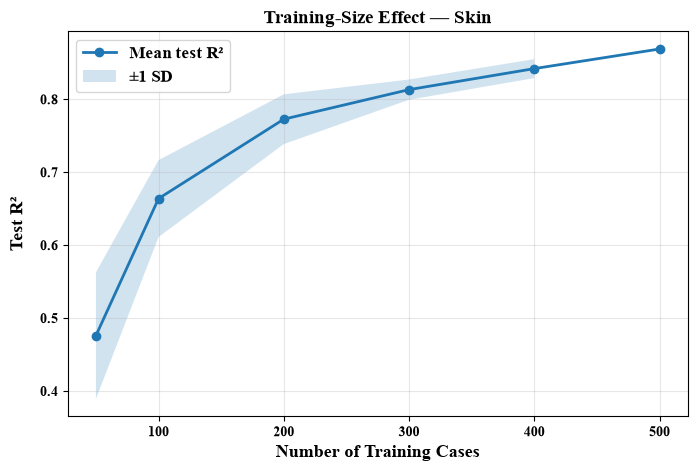

In [74]:
fig,ax = plt.subplots(figsize=(8, 5))

ax.plot(
    N,
    skin_mean,
    marker="o",
    linewidth=2,
    label="Mean test R²"
)

mask = ~np.isnan(skin_std)

ax.fill_between(
    N[mask],
    skin_mean[mask] - skin_std[mask],
    skin_mean[mask] + skin_std[mask],
    alpha=0.2,
    label="±1 SD"
)

ax.set_xlabel("Number of Training Cases", fontweight="bold", fontsize=13)
ax.set_ylabel("Test R²", fontweight="bold", fontsize=13, labelpad=10)
ax.set_title("Training-Size Effect — Skin", fontweight="bold", fontsize=14)

ax.legend()
ax.grid(True, which="both", alpha=0.3)

fig.savefig("Gradient Boosting_Training-Size Effect Skin Learning Curve Plot.jpeg", dpi = 300)

plt.show()

### Experiment 1 interpretation

The independent V2 study confirms the trend suggested by the original cross-validation learning curves. Permeability gains are strongest at smaller training sizes and then diminish, while skin continues to improve as training size increases. The decreasing spread across repeated random subsets also shows that larger training sets reduce sensitivity to which cases happen to be selected.

The V2 cases are used only for training in this experiment; the original V1 400-case set is used as the common evaluation set. The model settings are held fixed so that the primary changing variable is training-set size.


# Experiment 2 — Feature Representation

# Cell 48 — Load the original V1 processed transients

In [75]:
v1_curves = np.load(
    "well_test_processed_transients.npz"
)

print("Arrays stored in NPZ:")
print(v1_curves.files)

print("\nShapes:")
for name in v1_curves.files:
    print(name, v1_curves[name].shape)

Arrays stored in NPZ:
['case_id', 'time_hr', 'pressure_clean', 'pressure_noisy', 'pressure_smoothed', 'derivative_clean', 'derivative_observed']

Shapes:
case_id (500,)
time_hr (290,)
pressure_clean (500, 290)
pressure_noisy (500, 290)
pressure_smoothed (500, 290)
derivative_clean (500, 290)
derivative_observed (500, 290)


# Cell 49 — Verify V1 case IDs and time grid

In [76]:
v1_case_ids = v1_curves["case_id"]
v1_time = v1_curves["time_hr"]

print("Number of V1 cases:", len(v1_case_ids))
print("First 5 case IDs:", v1_case_ids[:5])
print("Last 5 case IDs:", v1_case_ids[-5:])

print(
    "\nCase IDs unique:",
    len(np.unique(v1_case_ids)) == len(v1_case_ids)
)

print(
    "Time grid matches current grid:",
    np.allclose(v1_time, time_dataset)
)

print(
    "All CSV case IDs found in NPZ:",
    set(df["case_id"]) == set(v1_case_ids)
)

Number of V1 cases: 500
First 5 case IDs: [0 1 2 3 4]
Last 5 case IDs: [495 496 497 498 499]

Case IDs unique: True
Time grid matches current grid: True
All CSV case IDs found in NPZ: True


# Cell 50 — Physics-feature extraction function

In [77]:
def extract_physics_features(time, pressure, derivative):

    # ----- 1. Early pressure slope: 0.001–0.01 hr -----
    early_mask = (
        (time >= 0.001) &
        (time <= 0.01)
    )

    early_P_slope = np.polyfit(
        np.log10(time[early_mask]),
        pressure[early_mask],
        1
    )[0]


    # ----- 2. Middle derivative median: 0.5–3 hr -----
    mid_mask = (
        (time >= 0.5) &
        (time <= 3.0)
    )

    mid_D_median = np.median(
        derivative[mid_mask]
    )


    # ----- 3. Late derivative slope: 10–30 hr -----
    late_mask = (
        (time >= 10.0) &
        (time <= 30.0)
    )

    late_D_slope = np.polyfit(
        np.log10(time[late_mask]),
        derivative[late_mask],
        1
    )[0]


    return {
        "early_P_slope": early_P_slope,
        "mid_D_median": mid_D_median,
        "late_D_slope": late_D_slope
    }

# Cell 51 — Calculate them for V1

In [78]:
v1_physics_rows = []

for i, case_id in enumerate(v1_case_ids):

    features = extract_physics_features(
        v1_time,
        v1_curves["pressure_smoothed"][i],
        v1_curves["derivative_observed"][i]
    )

    features["case_id"] = int(case_id)

    v1_physics_rows.append(features)


v1_physics_df = pd.DataFrame(v1_physics_rows)

print(v1_physics_df.shape)
v1_physics_df.head()

(500, 4)


,early_P_slope,mid_D_median,late_D_slope,case_id
0,30.875203,10.473717,-15.297734,0
1,14.337216,4.793230,40.543233,1
2,10.098762,16.353762,552.239568,2
3,12.627806,7.940622,65.962639,3
4,12.179064,30.174127,-27.411896,4


# Cell 52 — QC the V1 physics features

In [79]:
print(v1_physics_df.isna().sum())

print("\nAll values finite:")
print(
    np.isfinite(
        v1_physics_df[
            ["early_P_slope",
             "mid_D_median",
             "late_D_slope"]
        ]
    ).all().all()
)

print("\nFeature statistics:")
print(
    v1_physics_df[
        ["early_P_slope",
         "mid_D_median",
         "late_D_slope"]
    ].describe()
)

early_P_slope    0
mid_D_median     0
late_D_slope     0
case_id          0
dtype: int64

All values finite:
True

Feature statistics:
       early_P_slope  mid_D_median  late_D_slope
count     500.000000    500.000000    500.000000
mean       19.033195     16.225473     45.340039
std        10.609169     20.950179    118.292754
min         8.253654      0.491307    -64.051401
25%        11.358222      6.093306     -5.903317
50%        14.827187      8.839723      0.071487
75%        23.258685     17.265014     33.079234
max        61.194623    207.556135    734.237682


# Cell 53 — Extract physics features from V2

In [80]:
v2_physics_rows = []

for case in experimental_observed_cases:

    features = extract_physics_features(
        time_dataset,
        case["pressure_smoothed"],
        case["derivative_observed"]
    )

    features["case_id"] = int(case["case_id"])

    v2_physics_rows.append(features)


v2_physics_df = pd.DataFrame(v2_physics_rows)

print(v2_physics_df.shape)

print("\nMissing values:")
print(v2_physics_df.isna().sum())

print("\nAll physics features finite:")
print(
    np.isfinite(
        v2_physics_df[
            ["early_P_slope",
             "mid_D_median",
             "late_D_slope"]
        ]
    ).all().all()
)

v2_physics_df.head()

(500, 4)

Missing values:
early_P_slope    0
mid_D_median     0
late_D_slope     0
case_id          0
dtype: int64

All physics features finite:
True


,early_P_slope,mid_D_median,late_D_slope,case_id
0,12.263541,28.267239,112.474965,500
1,27.383527,6.463060,-9.714691,501
2,13.308531,9.742341,-12.486483,502
3,14.514569,11.008697,-5.150386,503
4,11.345137,11.089845,-3.988240,504


# Cell 54 — Merge physics features

In [81]:
# V1: original 500-case dataset
v1_extended = df.merge(
    v1_physics_df,
    on="case_id",
    how="left"
)

# V2: independent 500-case training dataset
v2_extended = experimental_df.merge(
    v2_physics_df,
    on="case_id",
    how="left"
)

physics_features = [
    "early_P_slope",
    "mid_D_median",
    "late_D_slope"
]

print("V1 extended shape:", v1_extended.shape)
print("V2 extended shape:", v2_extended.shape)

print("\nMissing V1 physics features:")
print(v1_extended[physics_features].isna().sum())

print("\nMissing V2 physics features:")
print(v2_extended[physics_features].isna().sum())

V1 extended shape: (500, 23)
V2 extended shape: (500, 22)

Missing V1 physics features:
early_P_slope    0
mid_D_median     0
late_D_slope     0
dtype: int64

Missing V2 physics features:
early_P_slope    0
mid_D_median     0
late_D_slope     0
dtype: int64


# Cell 55 — Build the controlled feature sets

In [82]:
feature_sets = {
    "Baseline_16":
        feature_columns,

    "Baseline + Early_P_slope":
        feature_columns + ["early_P_slope"],

    "Baseline + Mid_D_median":
        feature_columns + ["mid_D_median"],

    "Baseline + Late_D_slope":
        feature_columns + ["late_D_slope"],

    "Baseline + All_3":
        feature_columns + physics_features
}

for name, features in feature_sets.items():
    print(f"{name}: {len(features)} features")

Baseline_16: 16 features
Baseline + Early_P_slope: 17 features
Baseline + Mid_D_median: 17 features
Baseline + Late_D_slope: 17 features
Baseline + All_3: 19 features


# Cell 56 — Train and evaluate each feature set

In [83]:
feature_experiment_results = []

# V2 = all 500 independent training cases
# V1 = original frozen 400 test cases
v1_test_extended = v1_extended[
    v1_extended["split"] == "test"
].copy()

for set_name, features in feature_sets.items():

    X_train_feat = v2_extended[features]
    X_test_feat = v1_test_extended[features]

    # Separate models for the two targets
    model_k = GradientBoostingRegressor(random_state=42)
    model_skin = GradientBoostingRegressor(random_state=42)

    model_k.fit(
        X_train_feat,
        v2_extended["k_mD"]
    )

    model_skin.fit(
        X_train_feat,
        v2_extended["skin"]
    )

    pred_k = model_k.predict(X_test_feat)
    pred_skin = model_skin.predict(X_test_feat)

    feature_experiment_results.append({
        "Feature_Set": set_name,
        "N_Features": len(features),

        "k_R2": r2_score(
            v1_test_extended["k_mD"],
            pred_k
        ),

        "k_MAE": mean_absolute_error(
            v1_test_extended["k_mD"],
            pred_k
        ),

        "skin_R2": r2_score(
            v1_test_extended["skin"],
            pred_skin
        ),

        "skin_MAE": mean_absolute_error(
            v1_test_extended["skin"],
            pred_skin
        )
    })


feature_results_df = pd.DataFrame(
    feature_experiment_results
)

feature_results_df

,Feature_Set,N_Features,k_R2,k_MAE,skin_R2,skin_MAE
0,Baseline_16,16,0.987903,4.191366,0.869051,0.527755
1,Baseline + Early_P_slope,17,0.987983,4.147832,0.859070,0.538135
2,Baseline + Mid_D_median,17,0.988927,4.037953,0.867101,0.526229
3,Baseline + Late_D_slope,17,0.988208,4.134839,0.869814,0.526807
4,Baseline + All_3,19,0.988566,4.072303,0.861342,0.539178


# Cell 57 — Compare against the baseline

In [84]:
baseline_k_R2 = feature_results_df.loc[
    feature_results_df["Feature_Set"] == "Baseline_16",
    "k_R2"
].iloc[0]

baseline_skin_R2 = feature_results_df.loc[
    feature_results_df["Feature_Set"] == "Baseline_16",
    "skin_R2"
].iloc[0]


feature_results_df["Delta_k_R2"] = (
    feature_results_df["k_R2"] - baseline_k_R2
)

feature_results_df["Delta_skin_R2"] = (
    feature_results_df["skin_R2"] - baseline_skin_R2
)


feature_results_df[
    [
        "Feature_Set",
        "N_Features",
        "k_R2",
        "Delta_k_R2",
        "k_MAE",
        "skin_R2",
        "Delta_skin_R2",
        "skin_MAE"
    ]
]

,Feature_Set,N_Features,k_R2,Delta_k_R2,k_MAE,skin_R2,Delta_skin_R2,skin_MAE
0,Baseline_16,16,0.987903,0.000000,4.191366,0.869051,0.000000,0.527755
1,Baseline + Early_P_slope,17,0.987983,0.000079,4.147832,0.859070,-0.009981,0.538135
2,Baseline + Mid_D_median,17,0.988927,0.001023,4.037953,0.867101,-0.001951,0.526229
3,Baseline + Late_D_slope,17,0.988208,0.000305,4.134839,0.869814,0.000763,0.526807
4,Baseline + All_3,19,0.988566,0.000663,4.072303,0.861342,-0.007709,0.539178


### Experiment 2 interpretation

The three added physics-informed summary features provide little additional predictive information beyond the 16 baseline features. `mid_D_median` gives only a small permeability improvement, consistent with its connection to the radial-flow derivative, while the skin changes are negligible or unfavorable. Because these summary features are strongly related to information already present in the fixed-time samples, the **Baseline 16** representation is retained.


# Experiment 3 — Diagnose Skin Error

# Cell 58 — Refit baseline skin model and save case-level errors

In [85]:
baseline_skin_model = GradientBoostingRegressor(random_state=42)

baseline_skin_model.fit(
    v2_extended[feature_columns],
    v2_extended["skin"]
)

skin_pred = baseline_skin_model.predict(
    v1_test_extended[feature_columns]
)

skin_error_df = v1_test_extended[
    ["case_id", "skin"]
].copy()

skin_error_df["skin_pred"] = skin_pred

skin_error_df["error"] = (
    skin_error_df["skin_pred"] -
    skin_error_df["skin"]
)

skin_error_df["abs_error"] = np.abs(
    skin_error_df["error"]
)

skin_error_df.head()

,case_id,skin,skin_pred,error,abs_error
0,0,2.887132,2.548065,-0.339067,0.339067
2,2,0.166693,-0.108715,-0.275408,0.275408
3,3,3.696565,3.254787,-0.441778,0.441778
4,4,2.793118,3.840446,1.047328,1.047328
5,5,-0.861681,-0.191166,0.670515,0.670515


# Cell 59 — Does error depend on the true skin?

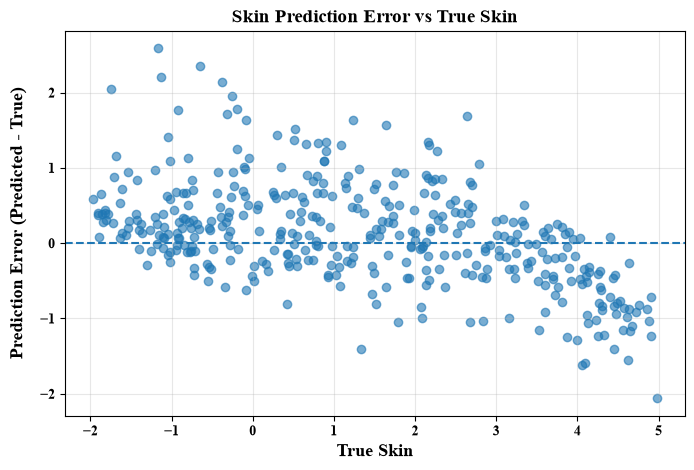

In [86]:
fig,ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    skin_error_df["skin"],
    skin_error_df["error"],
    alpha=0.6
)

ax.axhline(0, linestyle="--")

ax.set_xlabel("True Skin", fontweight="bold", fontsize=13)
ax.set_ylabel("Prediction Error (Predicted - True)", fontweight="bold", fontsize=13, labelpad=10)
ax.set_title("Skin Prediction Error vs True Skin", fontweight="bold", fontsize=14)

ax.grid(True, which="both", alpha=0.3)

fig.savefig("Gradient Boosting_Skin Prediction Error vs True Skin Plot.jpeg", dpi = 300)

plt.show()

# Cell 60 — Bin skin and calculate error statistics

In [87]:
skin_error_df["skin_bin"] = pd.cut(
    skin_error_df["skin"],
    bins=[-2, -1, 0, 1, 2, 3, 4, 5],
    include_lowest=True
)

skin_error_summary = (
    skin_error_df
    .groupby("skin_bin", observed=True)
    .agg(
        n_cases=("case_id", "count"),
        mean_error=("error", "mean"),
        mean_abs_error=("abs_error", "mean")
    )
)

skin_error_summary

,n_cases,mean_error,mean_abs_error
skin_bin,,,
"(-2.001, -1.0]",53,0.451530,0.492419
"(-1.0, 0.0]",73,0.417019,0.549867
"(0.0, 1.0]",64,0.326316,0.506368
"(1.0, 2.0]",54,0.174888,0.503169
"(2.0, 3.0]",58,0.175013,0.505956
"(3.0, 4.0]",52,-0.211416,0.339478
"(4.0, 5.0]",46,-0.826086,0.832317


# Cell 61 — Reconstruct V1 parameter metadata

In [88]:
np.random.seed(42)

n_cases = 500

v1_metadata = pd.DataFrame({
    "case_id": np.arange(n_cases),

    "k_check": np.random.uniform(
        20, 200, n_cases
    ),

    "skin_check": np.random.uniform(
        -2, 5, n_cases
    ),

    "C_bbl_per_psi": np.random.uniform(
        0.0025, 0.020, n_cases
    ),

    "re_ft": np.random.uniform(
        125, 1000, n_cases
    ),

    "boundary_type": np.random.choice(
        ["no_flow", "constant_pressure"],
        size=n_cases
    )
})

v1_metadata.head()

,case_id,k_check,skin_check,C_bbl_per_psi,re_ft,boundary_type
0,0,87.417221,2.887132,0.005740,579.196562,constant_pressure
1,1,191.128575,1.752675,0.011983,544.284143,no_flow
2,2,151.758910,0.166693,0.017777,147.436808,no_flow
3,3,127.758527,3.696565,0.015314,423.591849,no_flow
4,4,48.083355,2.793118,0.016615,457.671166,constant_pressure


# Cell 62 — Verify against saved V1 data

In [89]:
metadata_check = df.merge(
    v1_metadata[
        ["case_id", "k_check", "skin_check"]
    ],
    on="case_id"
)

print(
    "Maximum k difference:",
    np.max(
        np.abs(
            metadata_check["k_mD"]
            - metadata_check["k_check"]
        )
    )
)

print(
    "Maximum skin difference:",
    np.max(
        np.abs(
            metadata_check["skin"]
            - metadata_check["skin_check"]
        )
    )
)

Maximum k difference: 2.842170943040401e-14
Maximum skin difference: 8.881784197001252e-16


# Cell 63 — Attach nuisance parameters to the skin-error table

In [90]:
skin_error_df = skin_error_df.merge(
    v1_metadata[
        [
            "case_id",
            "C_bbl_per_psi",
            "re_ft",
            "boundary_type"
        ]
    ],
    on="case_id",
    how="left"
)

skin_error_df.head()

,case_id,skin,skin_pred,error,abs_error,skin_bin,C_bbl_per_psi,re_ft,boundary_type
0,0,2.887132,2.548065,-0.339067,0.339067,"(2.0, 3.0]",0.005740,579.196562,constant_pressure
1,2,0.166693,-0.108715,-0.275408,0.275408,"(0.0, 1.0]",0.017777,147.436808,no_flow
2,3,3.696565,3.254787,-0.441778,0.441778,"(3.0, 4.0]",0.015314,423.591849,no_flow
3,4,2.793118,3.840446,1.047328,1.047328,"(2.0, 3.0]",0.016615,457.671166,constant_pressure
4,5,-0.861681,-0.191166,0.670515,0.670515,"(-1.0, 0.0]",0.014029,473.969933,constant_pressure


In [91]:
print(skin_error_df[
    ["C_bbl_per_psi", "re_ft", "boundary_type"]
].isna().sum())

C_bbl_per_psi    0
re_ft            0
boundary_type    0
dtype: int64


# Cell 64 — Skin error vs wellbore storage

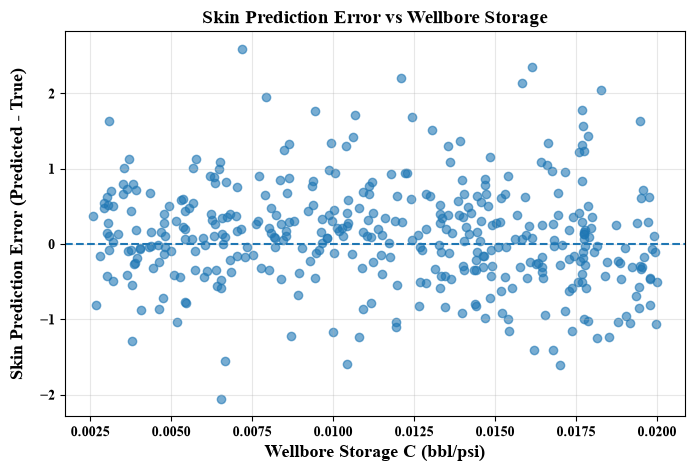

In [92]:
fig,ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    skin_error_df["C_bbl_per_psi"],
    skin_error_df["error"],
    alpha=0.6
)

ax.axhline(0, linestyle="--")

ax.set_xlabel("Wellbore Storage C (bbl/psi)", fontweight="bold", fontsize=13)
ax.set_ylabel("Skin Prediction Error (Predicted - True)", fontweight="bold", fontsize=13, labelpad=10)
ax.set_title("Skin Prediction Error vs Wellbore Storage", fontweight="bold", fontsize=14)

ax.grid(True, which="both", alpha=0.3)

fig.savefig("Gradient Boosting_Skin Prediction Error vs Wellbore Storage Plot.jpeg", dpi = 300)

plt.show()

# Cell 65 — Divide wellbore storage into low/mid/high groups

In [93]:
skin_error_df["C_group"] = pd.qcut(
    skin_error_df["C_bbl_per_psi"],
    q=3,
    labels=["Low C", "Medium C", "High C"]
)

skin_C_summary = (
    skin_error_df
    .groupby(["skin_bin", "C_group"], observed=True)
    .agg(
        n_cases=("case_id", "count"),
        mean_error=("error", "mean"),
        MAE=("abs_error", "mean")
    )
    .reset_index()
)

skin_C_summary

,skin_bin,C_group,n_cases,mean_error,MAE
0,"(-2.001, -1.0]",Low C,18,0.542677,0.544554
1,"(-2.001, -1.0]",Medium C,16,0.472231,0.520337
2,"(-2.001, -1.0]",High C,19,0.347748,0.419517
3,"(-1.0, 0.0]",Low C,26,0.531165,0.574040
4,"(-1.0, 0.0]",Medium C,21,0.405413,0.517548
5,"(-1.0, 0.0]",High C,26,0.312246,0.551797
6,"(0.0, 1.0]",Low C,18,0.278751,0.452996
7,"(0.0, 1.0]",Medium C,22,0.500335,0.564811
8,"(0.0, 1.0]",High C,24,0.202473,0.492824
9,"(1.0, 2.0]",Low C,22,0.301678,0.378484


# Cell 66 — Compare MAE across \(S\) and \(C\)

In [94]:
skin_C_pivot = skin_C_summary.pivot(
    index="skin_bin",
    columns="C_group",
    values="MAE"
)

skin_C_pivot

C_group,Low C,Medium C,High C
skin_bin,,,
"(-2.001, -1.0]",0.544554,0.520337,0.419517
"(-1.0, 0.0]",0.574040,0.517548,0.551797
"(0.0, 1.0]",0.452996,0.564811,0.492824
"(1.0, 2.0]",0.378484,0.590395,0.587988
"(2.0, 3.0]",0.423578,0.470128,0.646556
"(3.0, 4.0]",0.296174,0.249361,0.541409
"(4.0, 5.0]",0.656856,0.877619,0.959456


# Cell 67 — Compare skin error by boundary type

In [95]:
boundary_summary = (
    skin_error_df
    .groupby("boundary_type")
    .agg(
        n_cases=("case_id", "count"),
        mean_error=("error", "mean"),
        MAE=("abs_error", "mean")
    )
)

boundary_summary

,n_cases,mean_error,MAE
boundary_type,,,
constant_pressure,208,0.125624,0.549080
no_flow,192,0.102755,0.504653


In [96]:
skin_boundary_summary = (
    skin_error_df
    .groupby(
        ["skin_bin", "boundary_type"],
        observed=True
    )
    .agg(
        n_cases=("case_id", "count"),
        mean_error=("error", "mean"),
        MAE=("abs_error", "mean")
    )
    .reset_index()
)

skin_boundary_pivot = skin_boundary_summary.pivot(
    index="skin_bin",
    columns="boundary_type",
    values="MAE"
)

skin_boundary_pivot

boundary_type,constant_pressure,no_flow
skin_bin,,
"(-2.001, -1.0]",0.584716,0.396572
"(-1.0, 0.0]",0.599704,0.501376
"(0.0, 1.0]",0.535859,0.476877
"(1.0, 2.0]",0.519837,0.486502
"(2.0, 3.0]",0.481192,0.530721
"(3.0, 4.0]",0.356255,0.319904
"(4.0, 5.0]",0.748939,0.974550


# Cell 68 — Low/medium/high permeability diagnostic

In [97]:
k_metadata = v1_test_extended[
    ["case_id", "k_mD"]
]

skin_error_df = skin_error_df.merge(
    k_metadata,
    on="case_id",
    how="left"
)

skin_error_df["k_group"] = pd.qcut(
    skin_error_df["k_mD"],
    q=3,
    labels=["Low k", "Medium k", "High k"]
)

skin_k_summary = (
    skin_error_df
    .groupby(
        ["skin_bin", "k_group"],
        observed=True
    )
    .agg(
        n_cases=("case_id", "count"),
        MAE=("abs_error", "mean")
    )
    .reset_index()
)

skin_k_pivot = skin_k_summary.pivot(
    index="skin_bin",
    columns="k_group",
    values="MAE"
)

skin_k_pivot

k_group,Low k,Medium k,High k
skin_bin,,,
"(-2.001, -1.0]",0.945966,0.212540,0.221710
"(-1.0, 0.0]",0.793775,0.526311,0.239749
"(0.0, 1.0]",0.682387,0.507422,0.276594
"(1.0, 2.0]",0.517117,0.619152,0.413389
"(2.0, 3.0]",0.554587,0.411937,0.622920
"(3.0, 4.0]",0.413339,0.322305,0.321341
"(4.0, 5.0]",0.984413,0.729747,0.790426


### Experiment 3 interpretation

The dominant skin-error pattern is an extreme-value prediction bias / regression toward the center: predictions are pulled toward the center of the training range. The upper skin interval is the most difficult. The grouped diagnostics are consistent with a secondary interaction between skin and wellbore storage, especially at high skin. Boundary effects are secondary, and permeability does not show a consistent systematic relationship with the skin error.

A compact working interpretation is


$ 
\text{skin error}
\approx
\text{extreme-value/generalization effect}
+
\text{skin--storage interaction}
+
\text{secondary boundary effects}.$

This is a diagnostic interpretation of the present synthetic experiment, not a claim that the grouped variables are independently causal.


# Week 3 — Final Conclusions

### 1. Baseline model comparison
The nonlinear tree models substantially outperform the Ridge baseline. Gradient Boosting gives the strongest baseline performance on the frozen V1 test set, while permeability is predicted more accurately than skin.

### 2. Why permeability is easier
The feature-importance analysis is physically consistent with pressure-transient theory: the middle-time derivative dominates permeability prediction because the radial-flow derivative scales approximately as

$$\[p'_{\mathrm{radial}} \propto \frac{1}{k}]\$$


Permeability therefore has a strong, relatively direct diagnostic signature in the transient.

### 3. Training-size sensitivity
The independent V2 experiment shows that increasing the number of training cases improves both targets. Permeability improves rapidly and then shows diminishing returns, whereas skin continues to improve through 500 training cases. This indicates that skin remains more data-limited than permeability.

### 4. Physics-informed feature experiment
Adding `early_P_slope`, `mid_D_median`, and `late_D_slope` produces little improvement over the original 16 fixed-time features. These quantities are physically meaningful, but much of their information is already represented by the sampled pressure and derivative values. The 16-feature baseline is therefore retained.

### 5. Skin-error diagnosis
Skin errors show a clear regression-to-the-center pattern: low/negative skin tends to be overpredicted and high skin tends to be underpredicted. The largest errors occur at the upper skin extreme. Wellbore storage shows evidence of interacting with skin, particularly at high skin, while boundary type has a secondary effect. Permeability does not show a consistent monotonic relationship with skin error.

### Overall interpretation
The current workflow successfully learns permeability from the radial-flow signature. Skin is more difficult because its information is distributed across the early transition and pressure response and is partially entangled with wellbore-storage effects. More independent training data helps skin substantially, while the three tested summary features do not materially solve the remaining ambiguity.

### Methodological note
The original V1 400-case set is retained as the common test set for the Week 3 controlled experiments, allowing models trained on different datasets and feature representations to be compared on the same cases. Because its performance has been examined repeatedly during these experiments, a new independent holdout dataset should be reserved for final evaluation if future work involves extensive hyperparameter tuning or iterative model selection.
